# Tuần 02 — Tóm tắt dữ liệu (1/3)

**UET.MAT1052 — Xác suất thống kê**
ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

---

Không ai đọc hết 10.000 dòng dữ liệu để hiểu nó. Ta nén dữ liệu lại thành một bảng nhỏ, một biểu đồ, vài con số. Việc nén nào cũng bỏ đi một phần thông tin, nên câu hỏi của tuần này là: **một tóm tắt có thể đúng về số học mà vẫn trả lời sai câu hỏi không?** Câu trả lời là có, và ta sẽ gặp nhiều ví dụ.

Tuần này gồm ba phần nội dung:

- dữ liệu phân loại: bảng đếm, bảng liên hợp, tỉ lệ, mối liên hệ giữa hai biến phân loại;
- dữ liệu số: histogram, hình dạng, trung bình, trung vị;
- độ phân tán và biểu đồ hộp, rồi phản biện các tóm tắt gây hiểu nhầm.

Sau tuần này, bạn cần làm được:

1. Chọn cách tóm tắt dựa trên loại biến và câu hỏi đang hỏi.
2. Đọc bảng liên hợp (ô, tổng hàng, tổng cột, tổng chung) và chọn đúng mẫu số cho một câu hỏi về tỉ lệ.
3. Nhận ra mối liên hệ giữa hai biến phân loại qua phân phối có điều kiện, và diễn đạt nó mà không ngầm nói nhân quả.
4. Mô tả một phân phối số theo hình dạng, trung tâm, độ phân tán và giá trị ngoại lai.
5. Giải thích vì sao trung vị và IQR ít bị kéo bởi giá trị cực đoan hơn trung bình và SD, và vì sao trung bình là điểm làm tổng bình phương sai lệch nhỏ nhất.
6. Tự xây phản ví dụ cho các mệnh đề sai về tóm tắt, và suy ra tác động của phép đổi thang đo $Y = aX + b$.
7. Tìm mốt và đọc biểu đồ tròn, biết khi nào chúng hữu ích (bổ sung theo đề cương, LLO8.2–8.3).

**Mức độ bài tập** (giữ như trên lớp): `CORE` là kiến thức bắt buộc; `REASONING` cần giải thích hoặc nhiều bước; `CHALLENGE` không cho sẵn phương pháp; `DESIGN` yêu cầu tự xây dữ liệu hoặc phản ví dụ; `COMPUTE` dùng vài dòng code để kiểm chứng một lập luận. Bài khó là khó ở lập luận, không phải ở số dòng Python.

Tự trả lời trước khi mở đáp án thu gọn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Plotly cho các hình tương tác (thanh trượt, rê chuột xem tên, xoay 3D)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "notebook_connected+plotly_mimetype"
pio.templates.default = "simple_white"

pd.set_option("display.max_columns", 30)
rng = np.random.default_rng(42)
DATA = "datasets/"

# Tham số vẽ biểu đồ nằm ngang, tương thích Matplotlib cũ và mới
import matplotlib
NGANG = {"orientation": "horizontal"} if tuple(int(v) for v in matplotlib.__version__.split(".")[:2]) >= (3, 10) else {"vert": False}

> **W02-Q01 [CORE] — Nhớ lại Tuần 01.** Biến `species` nhận các giá trị Adelie, Chinstrap, Gentoo; biến `body_mass_g` ghi khối lượng cơ thể (gam).
> 1. Biến nào là phân loại, biến nào là số?
> 2. Bạn sẽ tóm tắt hai biến này bằng cùng một công cụ hay khác nhau?

<details><summary>Đáp án</summary>

`species` là biến phân loại, `body_mass_g` là biến số. Với `species`, bắt đầu bằng đếm số con mỗi loài hoặc tỉ lệ. Với `body_mass_g`, đếm từng giá trị không giúp gì nhiều (hầu như mỗi con một số khác nhau); cần nhìn hình dạng phân phối và các con số về trung tâm, độ phân tán.
</details>

> **W02-Q02 [CORE] — Cùng dữ liệu, khác câu hỏi.** Với dữ liệu chim cánh cụt Palmer, chọn cách tóm tắt mở đầu hợp lý nhất cho mỗi câu hỏi. Các lựa chọn: bảng đếm, bảng liên hợp, tỉ lệ có điều kiện, histogram, trung bình, trung vị.
> 1. Loài nào xuất hiện nhiều nhất?
> 2. Loài và đảo có liên hệ với nhau không?
> 3. Khối lượng cơ thể có phân phối lệch không?
> 4. Giá trị nào đại diện hợp lý cho khối lượng cơ thể "điển hình"?

<details><summary>Đáp án</summary>

(1) bảng đếm hoặc biểu đồ cột; (2) bảng liên hợp kèm tỉ lệ có điều kiện; (3) histogram; (4) trung bình hoặc trung vị, tùy hình dạng phân phối và mục đích. Phần còn lại của notebook giải thích vì sao.
</details>

---
## Phần 1. Dữ liệu phân loại

### 1.1 Từ data frame đến bảng đếm

Mở dữ liệu chim cánh cụt. Ta bỏ các con bị thiếu thông tin để có đúng 333 con như trong bài giảng STAT 20.

In [2]:
penguins = pd.read_csv(DATA + "penguins.csv").dropna()
print("Số con:", len(penguins))
penguins[["species", "island", "body_mass_g"]].head()

Số con: 333


,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
4,Adelie,Torgersen,3450.0
5,Adelie,Torgersen,3650.0


Nhìn 5 hàng đầu thì không thấy được gì về quan hệ giữa loài và đảo. Đếm số con theo từng cặp (loài, đảo) thì khác:

In [3]:
pd.crosstab(penguins["species"], penguins["island"], margins=True, margins_name="Tổng")

island,Biscoe,Dream,Torgersen,Tổng
species,,,,
Adelie,44,55,47,146
Chinstrap,0,68,0,68
Gentoo,119,0,0,119
Tổng,163,123,47,333


Bảng 4×4 này thay cho 333 dòng, và cho thấy ngay điều mà bảng thô giấu đi: Gentoo chỉ có ở Biscoe, Chinstrap chỉ có ở Dream, còn Adelie có ở cả ba đảo.

Hình dưới vẽ tay con đường đi từ data frame tới bảng đếm rồi tới biểu đồ, với 16 trong số 333 con chim.

<img src="figures/stat20_khung_du_lieu_bang_bieu_do.png" width="600">

*Hình 1.1. Từ data frame (trái) sang bảng liên hợp về số đếm (giữa, trên) và biểu đồ cột chồng (giữa, dưới), với 16 con chim cánh cụt. Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.2.1.*

Với cả 333 con, bảng liên hợp có thể vẽ thành **biểu đồ cột chồng** (mỗi cột là một loài, chia màu theo đảo) hoặc **biểu đồ cột nhóm** (các đảo đứng cạnh nhau trong mỗi loài).

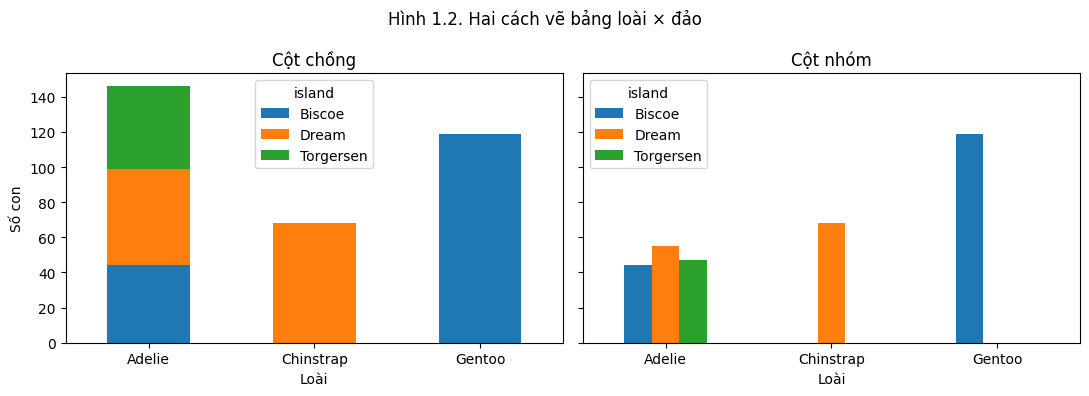

In [4]:
bang_loai_dao = pd.crosstab(penguins["species"], penguins["island"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
bang_loai_dao.plot(kind="bar", stacked=True, ax=axes[0], rot=0)
axes[0].set_title("Cột chồng")
bang_loai_dao.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Cột nhóm")
for ax in axes:
    ax.set_xlabel("Loài")
    ax.set_ylabel("Số con")
plt.suptitle("Hình 1.2. Hai cách vẽ bảng loài × đảo")
plt.tight_layout()
plt.show()

Cột chồng làm nổi bật tổng số con mỗi loài, ví dụ cột Adelie cao 146 (bằng tổng hàng Adelie). Cột nhóm làm tổng đó khó thấy hơn, nhưng dễ so xem Adelie ở đảo nào nhiều hơn.

### 1.2 Đọc bảng liên hợp trước khi tính

Bảng trên gọi là **bảng liên hợp** (contingency table): nó đếm số quan sát theo từng tổ hợp mức của hai biến phân loại. (Một số giáo trình tiếng Việt gọi là "bảng liên hợp"; học phần này dùng "bảng liên hợp".)

Trong bảng có ba loại số:

- **ô**: số quan sát có đồng thời một mức của biến hàng và một mức của biến cột;
- **tổng hàng, tổng cột** (còn gọi là số đếm biên): cộng dọc một hàng hoặc một cột;
- **tổng chung**: tất cả quan sát.

Ta dùng thêm bảng hành khách tàu Titanic (OpenIntro Statistics 4e, §2.2), phân theo nhóm tuổi và kết quả.

In [5]:
titanic = pd.DataFrame(
    {"Tử vong": [1438, 52], "Sống sót": [654, 57]},
    index=["Người lớn", "Trẻ em"],
)
titanic.index.name = "Tuổi"
titanic_day_du = titanic.copy()
titanic_day_du["Tổng"] = titanic_day_du.sum(axis=1)
titanic_day_du.loc["Tổng"] = titanic_day_du.sum()
titanic_day_du

,Tử vong,Sống sót,Tổng
Tuổi,,,
Người lớn,1438,654,2092
Trẻ em,52,57,109
Tổng,1490,711,2201


> **W02-EX01 [REASONING] — Đọc bảng liên hợp.**
> 1. Con số 654 mô tả nhóm nào?
> 2. 2092 là tổng của gì?
> 3. 711 là tổng của gì?
> 4. Bảng có bao nhiêu hành khách?
> 5. Viết một câu mô tả dữ liệu dựa trên một ô, không dùng từ "tỉ lệ".

<details><summary>Đáp án</summary>

654 là số người lớn sống sót. 2092 là tổng số người lớn (tổng hàng). 711 là tổng số người sống sót (tổng cột). Có 2201 hành khách. Ví dụ câu mô tả: "Có 52 hành khách là trẻ em và đã tử vong."
</details>

### 1.3 Đếm hay tỉ lệ?

> **W02-EX02 [REASONING].** Một sinh viên kết luận: "Người lớn có kết quả sống sót tốt hơn vì 654 > 57."
> 1. Lập luận sai ở đâu?
> 2. Chọn mẫu số đúng cho mỗi nhóm.
> 3. Tính tỉ lệ sống sót của người lớn và của trẻ em.
> 4. Viết lại kết luận bằng ngôn ngữ mô tả, không ngầm nói nhân quả.

Thử tự làm câu 2 và 3 bằng tay trước. Ô dưới để kiểm tra.

In [6]:
ti_le_song_nguoi_lon = 654 / 2092
ti_le_song_tre_em = 57 / 109
print(f"Người lớn: {ti_le_song_nguoi_lon:.1%}")
print(f"Trẻ em   : {ti_le_song_tre_em:.1%}")

Người lớn: 31.3%
Trẻ em   : 52.3%


<details><summary>Đáp án</summary>

Có 2092 người lớn nhưng chỉ 109 trẻ em, nên so số đếm thô là so hai nhóm có kích thước chênh nhau gần 20 lần. Muốn so "khả năng sống sót", phải chia cho số người trong từng nhóm: người lớn 654/2092 ≈ 31,3%, trẻ em 57/109 ≈ 52,3%.

Kết luận mô tả: "Trong bảng này, tỉ lệ sống sót của trẻ em cao hơn của người lớn." Kết luận ngược hẳn với câu ban đầu.
</details>

### 1.4 Một ô, ba mẫu số, ba câu hỏi

Cùng ô "Người lớn & Sống sót" = 654 có thể chia cho ba số khác nhau, và mỗi phép chia trả lời một câu hỏi khác:

| Phép chia | Trả lời câu hỏi |
|---|---|
| 654 / 2201 | Trong **toàn bộ hành khách**, bao nhiêu phần là người lớn sống sót? |
| 654 / 2092 | Trong **số người lớn**, bao nhiêu phần sống sót? |
| 654 / 711 | Trong **số người sống sót**, bao nhiêu phần là người lớn? |

Khi đọc hay viết một tỉ lệ, luôn nói rõ mẫu số là ai. pandas tính cả ba loại chỉ bằng tham số `normalize`:

In [7]:
print("Chia cho tổng chung:")
print(titanic.div(titanic.values.sum()).round(3), "\n")
print("Chia theo hàng (mỗi hàng cộng lại bằng 1):")
print(titanic.div(titanic.sum(axis=1), axis=0).round(3), "\n")
print("Chia theo cột (mỗi cột cộng lại bằng 1):")
print(titanic.div(titanic.sum(axis=0), axis=1).round(3))

Chia cho tổng chung:
           Tử vong  Sống sót
Tuổi                        
Người lớn    0.653     0.297
Trẻ em       0.024     0.026 

Chia theo hàng (mỗi hàng cộng lại bằng 1):
           Tử vong  Sống sót
Tuổi                        
Người lớn    0.687     0.313
Trẻ em       0.477     0.523 

Chia theo cột (mỗi cột cộng lại bằng 1):
           Tử vong  Sống sót
Tuổi                        
Người lớn    0.965      0.92
Trẻ em       0.035      0.08


> **W02-EX03 [REASONING] — Thử thách về mẫu số.** Xác định mẫu số trước, rồi viết phân số.
> A. Trong số người lớn, bao nhiêu phần sống sót?
> B. Trong số người sống sót, bao nhiêu phần là trẻ em?
> C. Trong toàn bộ hành khách, bao nhiêu phần là trẻ em sống sót?
>
> Câu trả lời "lấy số đếm chia cho tổng" không được chấp nhận nếu chưa nói rõ tổng nào.

<details><summary>Đáp án</summary>

A: mẫu số 2092, phân số 654/2092. B: mẫu số 711, phân số 57/711. C: mẫu số 2201, phân số 57/2201.
</details>

### 1.5 Phân phối biên, phân phối có điều kiện, mối liên hệ

**Phân phối biên** (marginal distribution) mô tả một biến mà không quan tâm tới biến kia. Ví dụ: trong toàn bộ bảng Titanic, bao nhiêu phần là người lớn, bao nhiêu phần là trẻ em.

**Phân phối có điều kiện** (conditional distribution) mô tả một biến *bên trong một nhóm* của biến kia. Ví dụ: trong nhóm người lớn, bao nhiêu phần sống, bao nhiêu phần chết.

Hai biến phân loại có **mối liên hệ** (association) nếu phân phối có điều kiện của biến này thay đổi khi đi từ nhóm này sang nhóm khác của biến kia. Ở Titanic, tỉ lệ sống sót là 31% ở người lớn và 52% ở trẻ em. Hai phân phối có điều kiện khác nhau rõ, nên trong dữ liệu này nhóm tuổi và kết quả có liên hệ với nhau.

Hướng điều kiện hóa cũng quan trọng. Với chim cánh cụt, "trong mỗi loài, các con sống ở đảo nào?" và "trên mỗi đảo, có những loài nào?" là hai câu chuyện khác nhau, dùng hai mẫu số khác nhau. **Biểu đồ cột chuẩn hóa** vẽ các tỉ lệ này: mỗi cột cao bằng 1 và được chia theo phân phối có điều kiện.

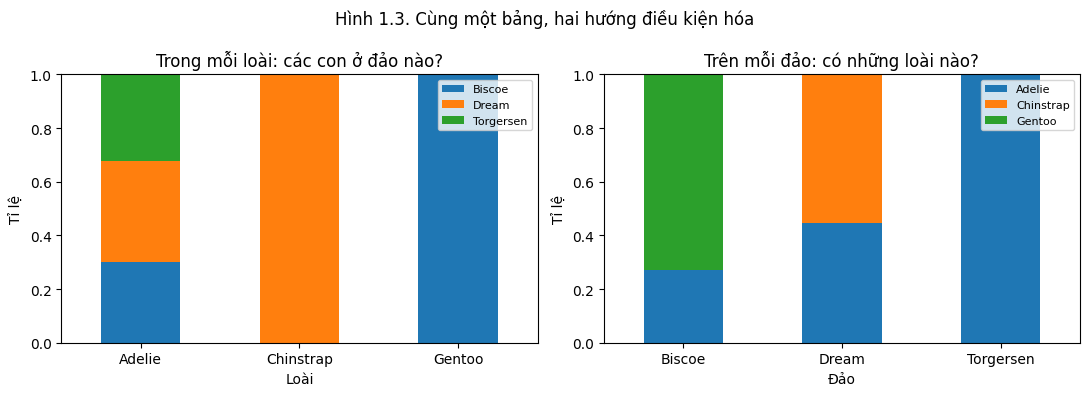

In [8]:
dao_trong_loai = pd.crosstab(penguins["species"], penguins["island"], normalize="index")
loai_tren_dao = pd.crosstab(penguins["island"], penguins["species"], normalize="index")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
dao_trong_loai.plot(kind="bar", stacked=True, ax=axes[0], rot=0)
axes[0].set_title("Trong mỗi loài: các con ở đảo nào?")
axes[0].set_xlabel("Loài")
loai_tren_dao.plot(kind="bar", stacked=True, ax=axes[1], rot=0)
axes[1].set_title("Trên mỗi đảo: có những loài nào?")
axes[1].set_xlabel("Đảo")
for ax in axes:
    ax.set_ylabel("Tỉ lệ")
    ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Hình 1.3. Cùng một bảng, hai hướng điều kiện hóa")
plt.tight_layout()
plt.show()

Ở hình phải, cột Biscoe cho thấy 119/163 ≈ 0,73 số chim trên đảo Biscoe là Gentoo. Ở hình trái, cột Gentoo cao toàn một màu, vì mọi con Gentoo đều ở Biscoe.

Làm sao nhìn ra mối liên hệ trên loại hình này? Nhìn lần lượt từ cột trái sang cột phải. Nếu cơ cấu màu thay đổi, hai biến có liên hệ. Nếu mọi cột có cùng cơ cấu, hai biến không liên hệ. Ô dưới đặt hình thật cạnh một bảng **giả định** trong đó mỗi đảo có cùng cơ cấu loài.

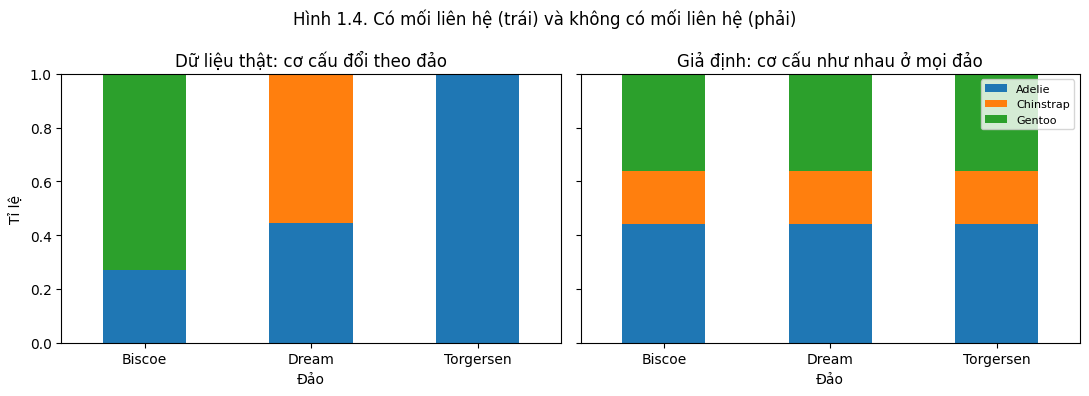

In [9]:
khong_lien_he = pd.DataFrame(
    {"Adelie": [0.44, 0.44, 0.44], "Chinstrap": [0.20, 0.20, 0.20], "Gentoo": [0.36, 0.36, 0.36]},
    index=["Biscoe", "Dream", "Torgersen"],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
loai_tren_dao.plot(kind="bar", stacked=True, ax=axes[0], rot=0, legend=False)
axes[0].set_title("Dữ liệu thật: cơ cấu đổi theo đảo")
khong_lien_he.plot(kind="bar", stacked=True, ax=axes[1], rot=0)
axes[1].set_title("Giả định: cơ cấu như nhau ở mọi đảo")
axes[1].legend(fontsize=8, loc="upper right")
for ax in axes:
    ax.set_xlabel("Đảo")
    ax.set_ylabel("Tỉ lệ")
plt.suptitle("Hình 1.4. Có mối liên hệ (trái) và không có mối liên hệ (phải)")
plt.tight_layout()
plt.show()

Ở hình phải, biết con chim sống ở đảo nào không giúp đoán loài của nó: cơ cấu luôn là khoảng 44% Adelie, 20% Chinstrap, 36% Gentoo. Ở hình trái, biết đảo thì biết khá nhiều về loài. Đó chính là ý nghĩa của "phân phối có điều kiện thay đổi".

> **W02-Q03 [CORE] — Mối liên hệ không phải nhân quả.** Phát biểu nào chặt chẽ hơn?
> A. "Tuổi gây ra khác biệt về khả năng sống sót."
> B. "Trong dữ liệu Titanic này, tỉ lệ sống sót khác nhau giữa hai nhóm tuổi."
> Vì sao phát biểu kia nói vượt quá những gì bảng liên hợp cho phép?

<details><summary>Đáp án</summary>

B. Bảng chỉ cho biết tỉ lệ khác nhau trong dữ liệu. Câu A là khẳng định nhân quả. Trên tàu Titanic, khác biệt này gắn với quy tắc ưu tiên phụ nữ và trẻ em lên xuồng cứu sinh, tức là do cách con người hành xử với từng nhóm, không phải do tuổi tự nó quyết định. Bảng không cho biết cơ chế đó; muốn nói nhân quả cần thêm lập luận và thiết kế (Tuần 12–13).
</details>

### 1.6 Ví dụ lớn hơn: 10.000 khoản vay

Introduction to Modern Statistics 2e dùng 10.000 khoản vay Lending Club, xét kiểu hồ sơ (một người đứng tên, `individual`, hay hai người, `joint`) và tình trạng nhà ở.

In [10]:
loans = pd.read_csv(DATA + "loans.csv")
pd.crosstab(loans["homeownership"], loans["application_type"], margins=True, margins_name="Tổng")

application_type,individual,joint,Tổng
homeownership,,,
MORTGAGE,3839,950,4789
OWN,1170,183,1353
RENT,3496,362,3858
Tổng,8505,1495,10000


**Dự đoán trước khi chạy:** hai con số dưới đây cùng dùng ô 362 hoặc ô 3496 nhưng với mẫu số khác. Con số nào sẽ lớn hơn nhiều?

In [11]:
theo_hang = pd.crosstab(loans["homeownership"], loans["application_type"], normalize="index")
theo_cot = pd.crosstab(loans["homeownership"], loans["application_type"], normalize="columns")

print(f"Trong số người thuê nhà (RENT), tỉ lệ hồ sơ joint     : {theo_hang.loc['RENT', 'joint']:.1%}")
print(f"Trong số hồ sơ individual, tỉ lệ là người thuê nhà  : {theo_cot.loc['RENT', 'individual']:.1%}")

Trong số người thuê nhà (RENT), tỉ lệ hồ sơ joint     : 9.4%
Trong số hồ sơ individual, tỉ lệ là người thuê nhà  : 41.1%


Khoảng 9% người thuê nhà nộp hồ sơ chung, nhưng khoảng 41% hồ sơ cá nhân là của người thuê nhà. Hai con số rất khác nhau vì chúng trả lời hai câu hỏi khác nhau.

### 1.7 Biểu đồ cột: số đếm hay tỉ lệ?

Bắt đầu với một biến: kết quả của hành khách. Biểu đồ cột có thể vẽ số đếm (tần số) hoặc tỉ lệ (tần suất tương đối).

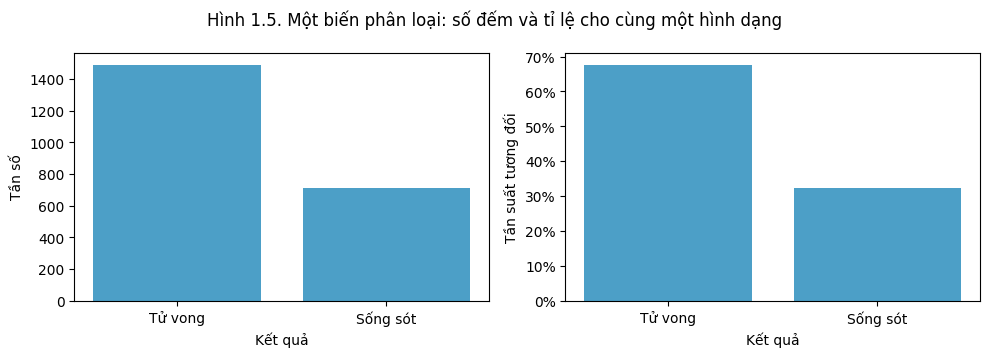

In [12]:
ket_qua = titanic.sum(axis=0)          # tổng theo cột: Tử vong, Sống sót

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(ket_qua.index, ket_qua.values, color="#4C9FC7")
axes[0].set_ylabel("Tần số")
axes[1].bar(ket_qua.index, ket_qua.values / ket_qua.sum(), color="#4C9FC7")
axes[1].set_ylabel("Tần suất tương đối")
axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
for ax in axes:
    ax.set_xlabel("Kết quả")
plt.suptitle("Hình 1.5. Một biến phân loại: số đếm và tỉ lệ cho cùng một hình dạng")
plt.tight_layout()
plt.show()

Với một biến, hai hình giống hệt nhau về hình dạng; chỉ trục tung đổi đơn vị. Sang hai biến thì khác. Trước khi nhìn các hình dưới, hãy nghĩ: nếu câu hỏi là "nhóm tuổi nào có tỉ lệ sống sót cao hơn", hình nào dễ khiến người xem kết luận sai?

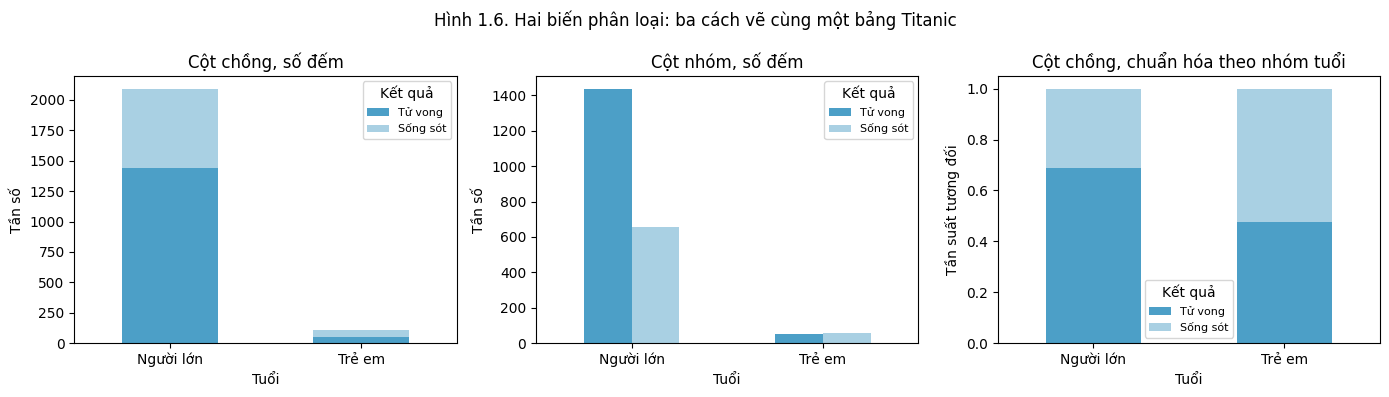

In [13]:
mau = ["#4C9FC7", "#A9D0E3"]
ti_le_theo_hang = titanic.div(titanic.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titanic.plot(kind="bar", stacked=True, ax=axes[0], rot=0, color=mau)
axes[0].set_title("Cột chồng, số đếm")
axes[0].set_ylabel("Tần số")
titanic.plot(kind="bar", ax=axes[1], rot=0, color=mau)
axes[1].set_title("Cột nhóm, số đếm")
axes[1].set_ylabel("Tần số")
ti_le_theo_hang.plot(kind="bar", stacked=True, ax=axes[2], rot=0, color=mau)
axes[2].set_title("Cột chồng, chuẩn hóa theo nhóm tuổi")
axes[2].set_ylabel("Tần suất tương đối")
for ax in axes:
    ax.set_xlabel("Tuổi")
    ax.legend(title="Kết quả", fontsize=8)
plt.suptitle("Hình 1.6. Hai biến phân loại: ba cách vẽ cùng một bảng Titanic")
plt.tight_layout()
plt.show()

Hai hình đầu nhấn mạnh **quy mô**: người lớn đông hơn hẳn, và phần "Sống sót" của người lớn to hơn hẳn của trẻ em. Mắt người xem dễ đọc thành "người lớn sống sót tốt hơn". Hình thứ ba chuẩn hóa mỗi nhóm về 1, nên nhấn mạnh **cơ cấu**: phần sống sót của trẻ em lớn hơn.

Cả hai hình đều đúng với dữ liệu. Nhưng một đồ thị đúng vẫn có thể phục vụ một lập luận sai nếu nó không khớp với câu hỏi.

Tóm lại, ba cách vẽ trong Hình 1.6 phục vụ ba mục đích: cột chồng theo số đếm để thấy tổng quy mô từng nhóm, cột nhóm để so số lượng từng ô, cột chồng chuẩn hóa để so tỉ lệ có điều kiện.

> **W02-EX04 [REASONING] — Biểu đồ cột hay histogram?** Đừng dựa vào việc các cột có chạm nhau hay không. Hãy dựa vào trục x.
> 1. Một biểu đồ có trục x là Adelie, Chinstrap, Gentoo.
> 2. Một biểu đồ có trục x là các khoảng 0–5, 5–10, 10–15 giờ/tuần.
> Biểu đồ nào là biểu đồ cột, biểu đồ nào là histogram?

<details><summary>Đáp án</summary>

(1) là biểu đồ cột: trục x là các nhóm, đổi thứ tự Adelie và Gentoo không làm mất thông tin. (2) là histogram: trục x là các khoảng liền nhau trên một thang số, thứ tự và độ rộng khoảng đều có nghĩa.
</details>

### 1.8 Biểu đồ tròn *(bổ sung theo đề cương, LLO8.3)*

Biểu đồ tròn cũng biểu diễn phân phối của **một** biến phân loại: mỗi lát là một nhóm, góc của lát tỉ lệ với tỉ lệ của nhóm. Nó chỉ trả lời câu "mỗi nhóm chiếm bao nhiêu phần của tổng", tức là cùng thông tin với biểu đồ cột tỉ lệ.

Mắt người so sánh độ dài tốt hơn nhiều so với góc hay diện tích. Vì vậy biểu đồ tròn dùng được khi có ít nhóm và các phần khác nhau rõ; khi nhiều nhóm hoặc các phần xấp xỉ nhau, biểu đồ cột dễ đọc hơn. Ô dưới vẽ cùng một biến theo hai cách.

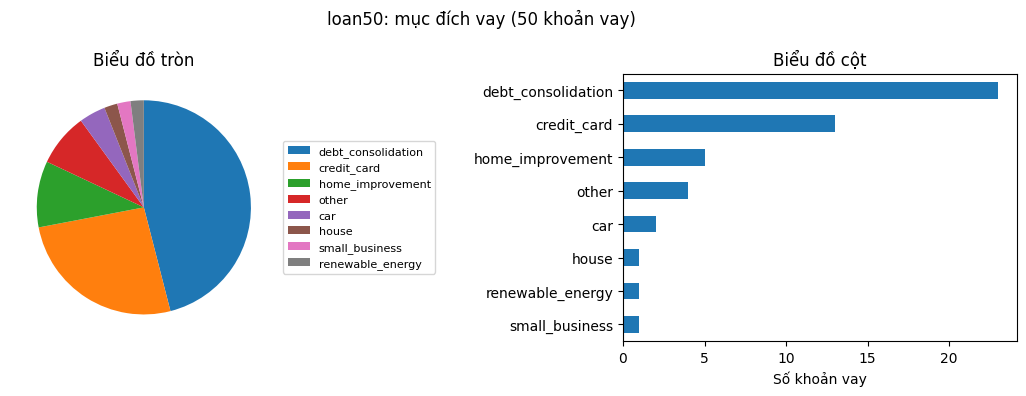

In [14]:
muc_dich_vay = pd.read_csv(DATA + "loan50.csv")["loan_purpose"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(muc_dich_vay, startangle=90, counterclock=False)
axes[0].legend(muc_dich_vay.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
axes[0].set_title("Biểu đồ tròn")
muc_dich_vay.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_xlabel("Số khoản vay")
axes[1].set_ylabel("")
axes[1].set_title("Biểu đồ cột")
plt.suptitle("loan50: mục đích vay (50 khoản vay)")
plt.tight_layout()
plt.show()

> **W02-BS01 [REASONING] (bổ sung).**
> 1. Từ biểu đồ tròn, bạn có sắp xếp được `home_improvement`, `other`, `car` theo thứ tự lớn nhỏ không? Còn từ biểu đồ cột?
> 2. Có thể vẽ bảng Titanic ở mục 1.2 (hai biến: tuổi và kết quả) bằng **một** biểu đồ tròn không? Nếu muốn so tỉ lệ sống sót giữa hai nhóm tuổi bằng biểu đồ tròn thì phải làm gì, và cách đó có tiện hơn cột chồng chuẩn hóa ở mục 1.7 không?
> 3. Có nên vẽ biểu đồ tròn cho `body_mass_g` không? Vì sao?

<details><summary>Đáp án</summary>

1. Với biểu đồ tròn, ba lát nhỏ (5, 4 và 2 khoản vay) rất khó so bằng mắt. Với biểu đồ cột đã sắp xếp, thứ tự hiện ra ngay.
2. Một biểu đồ tròn chỉ biểu diễn một phân phối. Muốn so tỉ lệ sống sót giữa hai nhóm tuổi phải vẽ hai biểu đồ tròn (một cho người lớn, một cho trẻ em), tức là hai phân phối có điều kiện. So hai góc ở hai hình khác nhau khó hơn so hai đoạn cột nằm cạnh nhau, nên cột chồng chuẩn hóa tiện hơn.
3. Không. `body_mass_g` là biến số; các lát sẽ là từng giá trị hoặc từng khoảng, và biểu đồ tròn làm mất thứ tự trên trục số. Dùng histogram.
</details>

> **W02-WP01 [REASONING] — Bài mẫu nhiều bước: tiêu đề này có đúng không?** Một bản tin viết: "Người lớn sống sót tốt hơn trẻ em vì có 654 người lớn sống sót nhưng chỉ 57 trẻ em sống sót." Đừng chọn công thức trước. Làm lần lượt:
> 1. Chữ "tốt hơn" đang ngầm so sánh đại lượng nào?
> 2. Chọn đúng hai mẫu số.
> 3. Tính hai tỉ lệ.
> 4. Đổi câu hỏi thành "trong số người sống sót, bao nhiêu phần là người lớn?"
> 5. Vì sao cùng ô 654 mà câu hỏi mới cần mẫu số khác?

<details><summary>Đáp án</summary>

1. "Sống sót tốt hơn" nghĩa là khả năng sống sót trong nhóm cao hơn, tức là tỉ lệ sống sót trong mỗi nhóm tuổi.
2. và 3. Người lớn 654/2092 ≈ 31,3%; trẻ em 57/109 ≈ 52,3%. Tiêu đề sai.
4. 654/711 ≈ 92,0%.
5. Câu hỏi mới lấy nhóm "người sống sót" làm tập tham chiếu, nên mẫu số là tổng cột. Con số 92% chỉ phản ánh việc trên tàu có rất nhiều người lớn, không nói gì về khả năng sống sót của người lớn.
</details>

---
## Phần 2. Dữ liệu số: hình dạng và trung tâm

Một con số tóm tắt (trung bình, trung vị, độ lệch chuẩn...) thực chất là một **hàm**: đưa cả bộ dữ liệu vào, lấy ra một con số. STAT 20 gọi mọi con số tính từ dữ liệu như vậy là một **thống kê** (statistic).

<img src="figures/stat20_thong_ke_la_ham.png" width="260">

*Hình 2.1. Một thống kê là một hàm $f$: đầu vào là dữ liệu $x$, đầu ra là con số $f(x)$. Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.4.3.*

Hàm nào cũng giữ lại một số đặc điểm và vứt bỏ những đặc điểm khác. Phần này hỏi: với một biến số, ta cần giữ lại những đặc điểm nào, và nên dùng hình hay số để giữ?

### 2.1 Khi số đếm chưa đủ

Với biến số, khoảng cách giữa các giá trị có nghĩa: GPA 3,6 gần 3,7 hơn là gần 2,9. Bảng đếm từng giá trị bỏ qua điều đó. Xét GPA của 193 sinh viên trong dữ liệu `gpa_study_hours` của OpenIntro (bỏ một giá trị 4,3 nằm ngoài thang 4).

In [15]:
gpa_hoc = pd.read_csv(DATA + "gpa_study_hours.csv")
gpa = gpa_hoc.loc[gpa_hoc["gpa"] <= 4.0, "gpa"]
print("Số sinh viên:", len(gpa), "  Số giá trị GPA khác nhau:", gpa.nunique())
gpa.value_counts().head(8)

Số sinh viên: 192   Số giá trị GPA khác nhau: 62


gpa
3.7    16
3.6    14
3.8    13
3.4    13
3.5    12
3.3    11
4.0     9
3.2     8
Name: count, dtype: int64

Có 62 giá trị khác nhau; nhiều giá trị chỉ xuất hiện một lần. Đọc bảng đếm này không thấy dữ liệu tập trung ở đâu. Cách đơn giản nhất để thấy là **dot plot** (biểu đồ chấm): mỗi sinh viên là một chấm đặt đúng vị trí GPA của mình trên trục số.

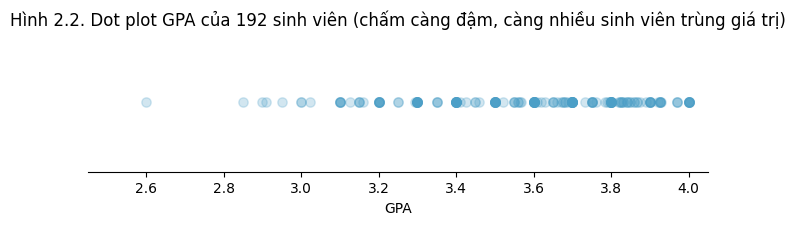

In [16]:
fig, ax = plt.subplots(figsize=(8, 1.8))
ax.scatter(gpa, np.zeros(len(gpa)), alpha=0.25, s=45, color="#4C9FC7")
ax.set_yticks([])
ax.set_xlim(2.45, 4.05)
ax.set_xlabel("GPA")
ax.set_title("Hình 2.2. Dot plot GPA của 192 sinh viên (chấm càng đậm, càng nhiều sinh viên trùng giá trị)")
for side in ["left", "right", "top"]:
    ax.spines[side].set_visible(False)
plt.show()

> **W02-Q04 [CORE] — Mô tả, đừng chỉ gọi tên biểu đồ.** Nhìn Hình 2.2 và mô tả phân phối GPA bằng bốn ý: **hình dạng**, **trung tâm**, **độ phân tán**, **giá trị ngoại lai** nếu có. Không cần đưa số chính xác nếu đồ thị không cho phép.

<details><summary>Đáp án</summary>

Các chấm dày đặc nhất trong khoảng 3,4–3,9 và thưa dần về phía GPA thấp: phân phối lệch trái (đuôi dài bên trái), bị chặn ở 4,0. Trung tâm khoảng 3,6. Phần lớn sinh viên nằm trong khoảng 3,0–4,0. Vài sinh viên có GPA dưới 2,9, riêng giá trị 2,6 tách khỏi phần còn lại và có thể xem là ngoại lai.

Bốn ý này là khung dùng cho mọi phân phối số trong khóa học.
</details>

### 2.2 Từ dot plot đến histogram

STAT 20 minh họa bằng một bộ dữ liệu rất nhỏ: chiều dài mỏ của 16 con chim cánh cụt đầu tiên trong dữ liệu Palmer.

<img src="figures/stat20_chieu_dai_mo.png" width="330">

*Hình 2.3. Chiều dài mỏ (bill length) được đo từ gốc đến chóp mỏ. Tranh: Allison Horst. Nguồn: STAT 20, bản dịch tiếng Việt, §2.4.1.*

[39.1, 39.5, 40.3, 36.7, 39.3, 38.9, 39.2, 41.1, 38.6, 34.6, 36.6, 38.7, 42.5, 34.4, 46.0, 37.8]


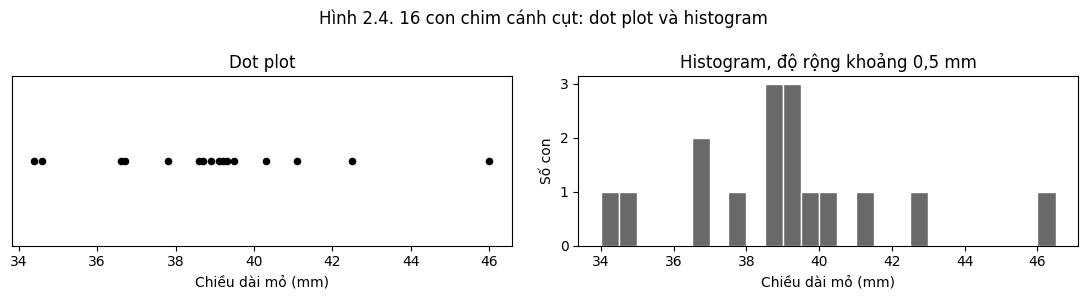

In [17]:
mo_16 = penguins["bill_length_mm"].head(16)
print(mo_16.tolist())

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].scatter(mo_16, np.zeros(16), color="black", s=20)
axes[0].set_yticks([])
axes[0].set_xlabel("Chiều dài mỏ (mm)")
axes[0].set_title("Dot plot")
axes[1].hist(mo_16, bins=np.arange(34, 47, 0.5), color="dimgray", edgecolor="white")
axes[1].set_xlabel("Chiều dài mỏ (mm)")
axes[1].set_ylabel("Số con")
axes[1].set_title("Histogram, độ rộng khoảng 0,5 mm")
plt.suptitle("Hình 2.4. 16 con chim cánh cụt: dot plot và histogram")
plt.tight_layout()
plt.show()

Dot plot giữ nguyên từng giá trị. Khi dữ liệu nhiều lên, các chấm chồng lên nhau và khó đọc. **Histogram** giải quyết việc đó: chia trục số thành các khoảng liền nhau, đếm số quan sát rơi vào mỗi khoảng, rồi vẽ mỗi khoảng thành một cột. Ta mất vị trí chính xác của từng quan sát, đổi lại thấy được hình dạng chung.

Hình dưới là histogram từ OpenIntro Statistics 4e về số giờ mỗi tuần sinh viên dành cho hoạt động ngoại khóa. OpenIntro không công bố dữ liệu gốc của hình này, nên ô code **mô phỏng** 196 giá trị có cùng hình dạng để vẽ lại.

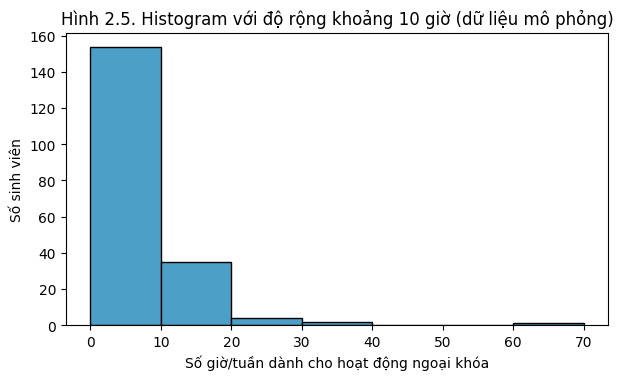

In [18]:
# Mô phỏng dữ liệu "giờ ngoại khóa mỗi tuần" có hình dạng như hình trong OpenIntro Statistics 4e
gio_ngoai_khoa = np.round(rng.exponential(scale=7, size=195), 1)
gio_ngoai_khoa = np.append(gio_ngoai_khoa, 62.0)           # một sinh viên khai 62 giờ/tuần
gio_ngoai_khoa = pd.Series(gio_ngoai_khoa)

plt.figure(figsize=(7, 3.8))
plt.hist(gio_ngoai_khoa, bins=np.arange(0, 80, 10), color="#4C9FC7", edgecolor="black")
plt.xlabel("Số giờ/tuần dành cho hoạt động ngoại khóa")
plt.ylabel("Số sinh viên")
plt.title("Hình 2.5. Histogram với độ rộng khoảng 10 giờ (dữ liệu mô phỏng)")
plt.show()

### 2.3 Độ rộng khoảng chia là một quyết định

Độ rộng khoảng do người vẽ chọn. Chọn khác đi thì hình khác đi.

> **W02-EX05 [REASONING] — Cùng dữ liệu, khác độ rộng khoảng chia.** Chạy ô dưới, kéo thanh trượt qua các độ rộng khoảng rồi trả lời: đặc điểm nào ổn định qua các cách chia? Đặc điểm nào thay đổi? Có nên kết luận chắc chắn về số đỉnh chỉ từ một lựa chọn độ rộng khoảng không?

In [19]:
# Kéo thanh trượt dưới hình để đổi độ rộng khoảng (giờ)
cac_do_rong = [50, 20, 10, 5, 2, 1]
mac_dinh = 10

fig = go.Figure()
for w in cac_do_rong:
    fig.add_trace(go.Histogram(
        x=gio_ngoai_khoa, xbins=dict(start=0, end=100, size=w), visible=(w == mac_dinh),
        marker=dict(color="#4C9FC7", line=dict(color="black", width=1)),
        hovertemplate="khoảng quanh %{x} giờ: %{y} sinh viên<extra></extra>"))
buoc = [dict(method="update", label=str(w), args=[{"visible": [v == w for v in cac_do_rong]}])
        for w in cac_do_rong]
fig.update_layout(
    title="Hình 2.6. Cùng dữ liệu, đổi độ rộng khoảng chia",
    xaxis_title="Giờ ngoại khóa/tuần", yaxis_title="Số sinh viên", bargap=0, showlegend=False,
    width=760, height=460,
    sliders=[dict(active=cac_do_rong.index(mac_dinh), steps=buoc, pad={"t": 50},
                  currentvalue={"prefix": "Độ rộng khoảng (giờ): "})])
fig.update_xaxes(range=[0, 100])
fig.show()

<details><summary>Đáp án</summary>

Ổn định: phần lớn sinh viên dồn ở vùng giá trị thấp, đuôi kéo dài về bên phải, và có vài sinh viên khai rất nhiều giờ. Thay đổi: với độ rộng 50, gần như mọi thứ dồn vào một cột và hình không còn nói gì; với độ rộng 2, xuất hiện nhiều đỉnh nhỏ, khoảng trống và cột lẻ, phần lớn là dao động ngẫu nhiên. Không nên kết luận số đỉnh từ một cách chia duy nhất; hãy thử vài độ rộng.

STAT 20 có một câu nhắc vui: dữ liệu luôn có thể được "tra tấn" cho đến khi chịu khai điều ta muốn nghe. Đổi độ rộng khoảng để tìm một hình "đẹp" cho kết luận có sẵn là một ví dụ.
</details>

### 2.4 Biểu đồ mật độ và violin plot *(bổ sung từ STAT 20, §2.4.1.2–2.4.1.3)*

Một histogram lởm chởm hay mịn phụ thuộc vào độ rộng khoảng. **Biểu đồ mật độ** (density plot) thay các cột bằng một đường cong mượt, xây bằng cách đặt một "gò" nhỏ lên mỗi quan sát rồi cộng các gò lại. Độ rộng của mỗi gò gọi là **băng thông** (bandwidth), đóng vai trò giống độ rộng khoảng. Trục tung không còn là số đếm mà là *mật độ*, được chuẩn hóa để diện tích dưới đường cong bằng 1; Tuần 07 sẽ định nghĩa kỹ khái niệm này.

Ô dưới vẽ histogram và đường mật độ cho 16 con chim cánh cụt ở Hình 2.4. Kéo thanh trượt để dùng cùng một con số cho độ rộng khoảng và băng thông: băng thông nhỏ thì đường cong bám sát từng quan sát, băng thông lớn thì mọi chi tiết bị là phẳng.

In [20]:
from scipy import stats

# Kéo thanh trượt: cùng một con số h dùng làm độ rộng khoảng (trái) và băng thông (phải)
cac_muc = [0.2, 0.5, 1, 1.5, 3, 5]
mac_dinh = 1.5

luoi_x = np.linspace(31, 48, 400)
fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram", "Biểu đồ mật độ"))
for h in cac_muc:
    fig.add_trace(go.Histogram(x=mo_16, xbins=dict(start=31, end=48, size=h), visible=(h == mac_dinh),
                               marker=dict(color="dimgray", line=dict(color="white", width=1)),
                               hovertemplate="%{y} con<extra></extra>"), row=1, col=1)
    kde = stats.gaussian_kde(mo_16, bw_method=h / mo_16.std())
    fig.add_trace(go.Scatter(x=luoi_x, y=kde(luoi_x), mode="lines", line=dict(color="black"), visible=(h == mac_dinh),
                             hovertemplate="%{x:.1f} mm: mật độ %{y:.3f}<extra></extra>"), row=1, col=2)
buoc = [dict(method="update", label=str(h), args=[{"visible": [v == h for v in cac_muc for _ in range(2)]}])
        for h in cac_muc]
fig.update_layout(
    title="Hình 2.7. Độ rộng khoảng và băng thông quyết định mức chi tiết",
    showlegend=False, bargap=0, width=900, height=430,
    sliders=[dict(active=cac_muc.index(mac_dinh), steps=buoc, pad={"t": 50},
                  currentvalue={"prefix": "Độ rộng khoảng = băng thông = "})])
fig.update_xaxes(range=[31, 48], title_text="Chiều dài mỏ (mm)")
fig.show()

Khi cần so sánh một biến số giữa vài nhóm, có thể đặt các đường mật độ cạnh nhau và lấy đối xứng qua trục: đó là **violin plot**. Hình dưới so chiều dài mỏ của ba loài bằng violin và bằng biểu đồ hộp (biểu đồ hộp sẽ học ở Phần 3).

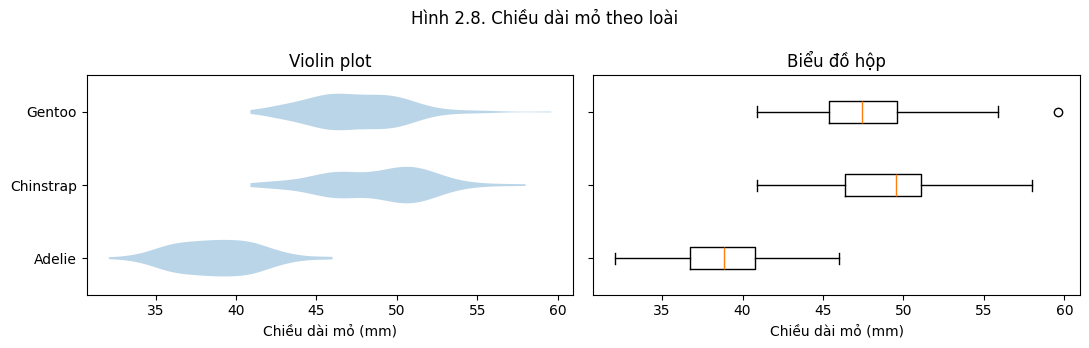

In [21]:
cac_loai = ["Adelie", "Chinstrap", "Gentoo"]
mo_theo_loai = [penguins.loc[penguins["species"] == loai, "bill_length_mm"] for loai in cac_loai]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
axes[0].violinplot(mo_theo_loai, showextrema=False, **NGANG)
axes[0].set_title("Violin plot")
axes[1].boxplot(mo_theo_loai, **NGANG)
axes[1].set_title("Biểu đồ hộp")
axes[0].set_yticks([1, 2, 3], cac_loai)
for ax in axes:
    ax.set_xlabel("Chiều dài mỏ (mm)")
plt.suptitle("Hình 2.8. Chiều dài mỏ theo loài")
plt.tight_layout()
plt.show()

Cả hai hình kể cùng một câu chuyện: Adelie có mỏ ngắn hơn hẳn Chinstrap và Gentoo. Violin cho thấy thêm hình dạng bên trong mỗi nhóm; biểu đồ hộp tính nhanh và gọn hơn nhưng giấu hình dạng đó đi.

### 2.5 Đọc một bảng tần số: lãi suất trong `loan50`

In [22]:
loan50 = pd.read_csv(DATA + "loan50.csv")
cac_moc = [5, 7.5, 10, 12.5, 15, 17.5, 20, 30]
bang_tan_so = pd.cut(loan50["interest_rate"], bins=cac_moc).value_counts().sort_index()
print(bang_tan_so)
print("\nTrung bình lãi suất của 50 khoản vay:", round(loan50["interest_rate"].mean(), 2), "%")

interest_rate
(5.0, 7.5]      11
(7.5, 10.0]     15
(10.0, 12.5]     8
(12.5, 15.0]     4
(15.0, 17.5]     5
(17.5, 20.0]     4
(20.0, 30.0]     3
Name: count, dtype: int64

Trung bình lãi suất của 50 khoản vay: 11.57 %


Phần lớn khoản vay có lãi suất dưới 15%, nhưng có một đuôi kéo về phía lãi suất cao: phân phối lệch phải. Con số 11,57% cho biết một vị trí trung tâm, nhưng không nói gì về cái đuôi đó. Một con số về trung tâm không thay được việc nhìn hình dạng.

### 2.6 Hình dạng: số đỉnh và độ lệch (skewness)

Khi mô tả hình dạng bằng lời, để ý hai điều. **Số đỉnh** (modality): phân phối có một đỉnh, hai đỉnh, nhiều đỉnh, hay gần như phẳng. **Độ lệch** (skew): đuôi bên phải dài hơn (lệch phải), đuôi bên trái dài hơn (lệch trái), hay hai đuôi dài như nhau (đối xứng).

<img src="figures/stat20_so_dinh.png" width="620">

*Hình 2.9. Một đỉnh (unimodal), hai đỉnh (bimodal), nhiều đỉnh (multimodal), phân phối đều (uniform). Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.4.2.*

<img src="figures/stat20_do_xien.png" width="620">

*Hình 2.10. Lệch phải (right skew), lệch trái (left skew), đối xứng (symmetric). Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.4.2.*

Với dữ liệu thật, hình không bao giờ gọn như hình phác thảo. Ô dưới **mô phỏng** các histogram cùng loại như trong OpenIntro Statistics 4e (§2.1).

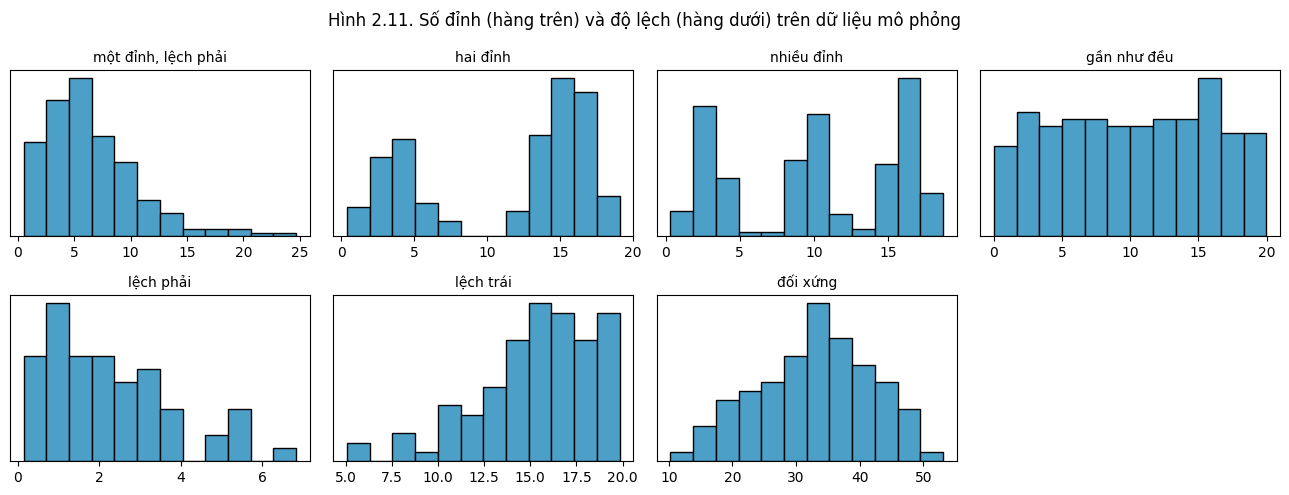

In [23]:
n = 200
hinh_dang = {
    "một đỉnh, lệch phải": rng.gamma(2.5, 2.5, n),
    "hai đỉnh": np.concatenate([rng.normal(4, 1.5, 70), rng.normal(15.5, 1.5, 130)]),
    "nhiều đỉnh": np.concatenate([rng.normal(3, 1, 60), rng.normal(10, 1, 60), rng.normal(16, 1.2, 80)]),
    "gần như đều": rng.uniform(0, 20, n),
    "lệch phải": rng.gamma(2, 1.2, 60),
    "lệch trái": 20 - rng.gamma(2, 2.2, 100),
    "đối xứng": rng.normal(35, 9, 100),
}
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for ax, (ten, du_lieu) in zip(axes.flat, hinh_dang.items()):
    ax.hist(du_lieu, bins=12, color="#4C9FC7", edgecolor="black")
    ax.set_title(ten, fontsize=10)
    ax.set_yticks([])
axes.flat[-1].axis("off")
plt.suptitle("Hình 2.11. Số đỉnh (hàng trên) và độ lệch (hàng dưới) trên dữ liệu mô phỏng")
plt.tight_layout()
plt.show()

Nhiều đỉnh thường là dấu hiệu có điều gì đó đáng tìm hiểu. Chiều dài mỏ của 16 con Adelie ở Hình 2.4 chỉ có một đỉnh rõ quanh 39 mm. Nhưng khi vẽ cho toàn bộ chim cánh cụt, xuất hiện hai đỉnh. Ô dưới vẽ cả hai, rồi tách theo loài để xem hai đỉnh đến từ đâu (Tuần 03 sẽ học kỹ cách tách nhóm này).

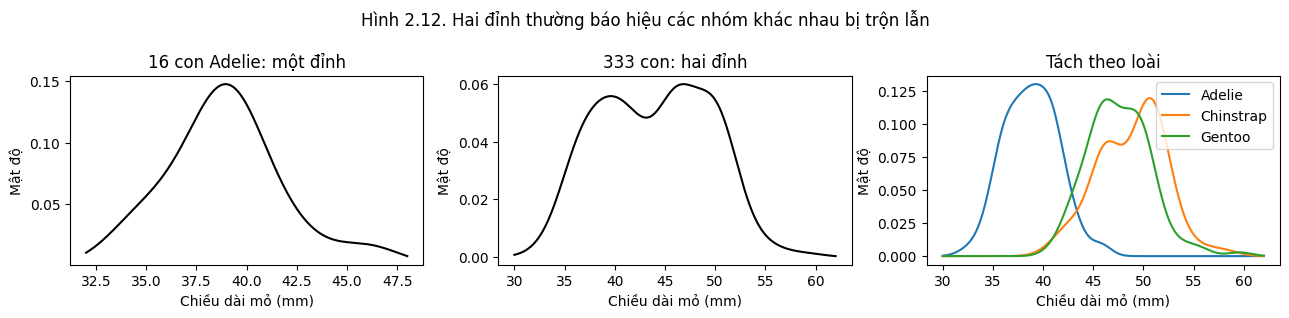

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
x_mo = np.linspace(30, 62, 400)
axes[0].plot(np.linspace(32, 48, 300), stats.gaussian_kde(mo_16)(np.linspace(32, 48, 300)), color="black")
axes[0].set_title("16 con Adelie: một đỉnh")
axes[1].plot(x_mo, stats.gaussian_kde(penguins["bill_length_mm"])(x_mo), color="black")
axes[1].set_title("333 con: hai đỉnh")
for loai, mo in zip(cac_loai, mo_theo_loai):
    axes[2].plot(x_mo, stats.gaussian_kde(mo)(x_mo), label=loai)
axes[2].set_title("Tách theo loài")
axes[2].legend()
for ax in axes:
    ax.set_xlabel("Chiều dài mỏ (mm)")
    ax.set_ylabel("Mật độ")
plt.suptitle("Hình 2.12. Hai đỉnh thường báo hiệu các nhóm khác nhau bị trộn lẫn")
plt.tight_layout()
plt.show()

Đỉnh bên trái chủ yếu là Adelie, đỉnh bên phải là Chinstrap và Gentoo, hai loài có mỏ dài hơn.

Một ví dụ quen thuộc của phân phối lệch phải là thu nhập hộ gia đình: nhóm giàu nhất có thu nhập cao hơn phần đông rất nhiều, trong khi nhóm nghèo nhất chỉ thấp hơn phần đông một chút.

<img src="figures/stat20_thu_nhap_ho_gia_dinh_2014.png" width="520">

*Hình 2.13. Phân phối thu nhập hộ gia đình Hoa Kỳ năm 2014, với các mốc phân vị 10%, 50%, 90%, 95%. Nguồn số liệu: U.S. Census Bureau, Current Population Survey 2015. Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.4.2.*

Mô tả bằng lời luôn cần một chút phán đoán: một gò nhỏ có đủ nổi bật để gọi là đỉnh thứ hai không? Hãy nêu những đặc điểm liên quan đến câu hỏi đang hỏi, đừng liệt kê máy móc.

### 2.7 Giá trị ngoại lai

Một quan sát nằm xa phần lớn dữ liệu có thể là giá trị thật nhưng hiếm, dấu hiệu của một nhóm khác lẫn vào, hoặc lỗi đo, lỗi nhập. Đừng xóa một điểm chỉ vì nó làm kết quả khó coi; hãy tìm hiểu nó trước.

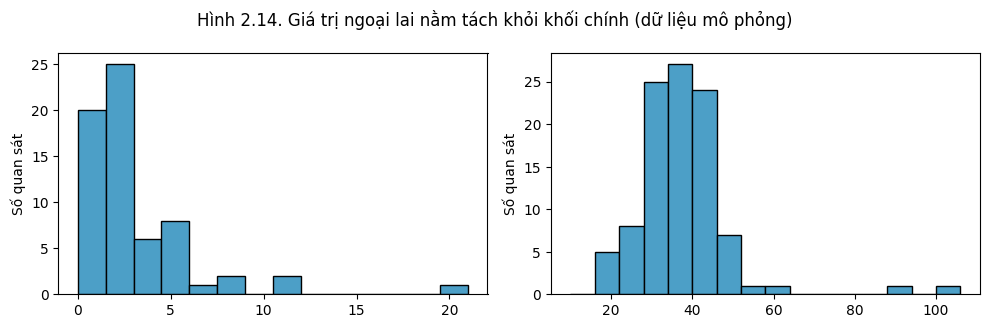

In [25]:
# Mô phỏng hai histogram có giá trị ngoại lai, như hình trong OpenIntro Statistics 4e (§2.1)
lech_voi_ngoai_lai = np.append(np.round(rng.gamma(1.6, 1.8, 64), 1), 19.5)
doi_xung_voi_ngoai_lai = np.append(rng.normal(37, 8, 98), [92, 101])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
axes[0].hist(lech_voi_ngoai_lai, bins=np.arange(0, 22, 1.5), color="#4C9FC7", edgecolor="black")
axes[1].hist(doi_xung_voi_ngoai_lai, bins=np.arange(10, 110, 6), color="#4C9FC7", edgecolor="black")
for ax in axes:
    ax.set_ylabel("Số quan sát")
plt.suptitle("Hình 2.14. Giá trị ngoại lai nằm tách khỏi khối chính (dữ liệu mô phỏng)")
plt.tight_layout()
plt.show()

> **W02-EX06 [REASONING] — Mô tả một phân phối.** Quay lại histogram số giờ hoạt động ngoại khóa (Hình 2.5). Viết 2–3 câu mô tả có đủ hình dạng, trung tâm ở mức xấp xỉ, độ phân tán ở mức quan sát được, và quan sát ngoại lai. Sau đó chỉ ra một điều bạn **không** thể biết chính xác chỉ từ histogram.

<details><summary>Đáp án</summary>

Phân phối có một đỉnh ở khoảng 0–10 giờ, lệch phải với đuôi kéo dài: phần lớn sinh viên dành dưới 20 giờ mỗi tuần, số người giảm nhanh khi số giờ tăng. Một quan sát ở khoảng 60 giờ/tuần tách hẳn khỏi phần còn lại và trông bất thường (có thể là số liệu thật, cũng có thể là khai sai).

Histogram không cho biết giá trị của từng sinh viên, cũng không cho biết chính xác trung bình hay trung vị.
</details>

### 2.8 Trung bình

Với dữ liệu $x_1, x_2, \dots, x_n$, **trung bình mẫu** là

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i .
$$

Trong đó $n$ là số quan sát, $x_i$ là giá trị thứ $i$, và $\sum$ là cộng tất cả lại. Trung bình dùng *độ lớn* của mọi giá trị. Có thể hình dung đặt các quan sát lên một thanh cân: trung bình là điểm tựa để thanh cân thăng bằng. Vì vậy một giá trị rất xa có thể kéo trung bình đi nhiều.

Ví dụ của STAT 20 dùng 11 giá trị:

In [26]:
x = pd.Series([8, 11, 7, 7, 8, 11, 9, 6, 10, 7, 9])
print("Trung bình:", round(x.mean(), 2))

Trung bình: 8.45


### 2.9 Vì sao lại là trung bình? Một câu hỏi về sai số

Giả sử bạn phải chọn **một con số** $c$ để đại diện cho cả 11 giá trị trên. Chọn $c$ nào thì tốt?

Cần một cách đo "tốt". Một cách tự nhiên: với mỗi quan sát, sai lệch là $x_i - c$; bình phương lên cho khỏi âm và phạt nặng sai lệch lớn; rồi cộng lại:

$$
L(c) = \sum_{i=1}^{n} (x_i - c)^2 .
$$

$L(c)$ càng nhỏ thì $c$ càng "gần" dữ liệu theo nghĩa này. Trước khi làm toán, thử tính $L(c)$ cho nhiều giá trị $c$ và vẽ ra.

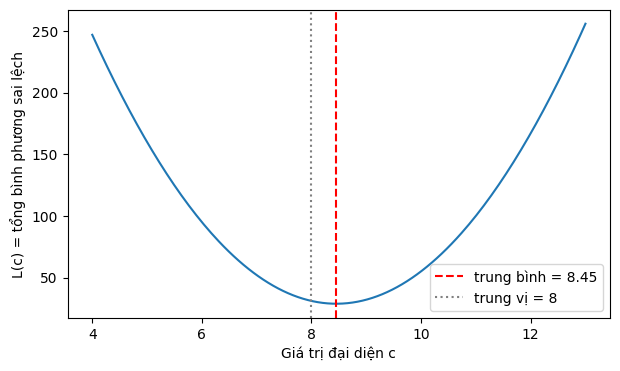

In [27]:
cac_gia_tri_c = np.linspace(4, 13, 200)
tong_binh_phuong = [((x - c) ** 2).sum() for c in cac_gia_tri_c]

plt.figure(figsize=(7, 4))
plt.plot(cac_gia_tri_c, tong_binh_phuong)
plt.axvline(x.mean(), color="red", linestyle="--", label=f"trung bình = {x.mean():.2f}")
plt.axvline(x.median(), color="gray", linestyle=":", label=f"trung vị = {x.median():.0f}")
plt.xlabel("Giá trị đại diện c")
plt.ylabel("L(c) = tổng bình phương sai lệch")
plt.legend()
plt.show()

Đường cong có dạng parabol và thấp nhất đúng tại trung bình. Điều này luôn đúng, không chỉ với bộ số này. Có hai cách thấy.

**Bằng đạo hàm.** $L'(c) = -2\sum_{i=1}^{n}(x_i - c) = 2nc - 2\sum_{i=1}^{n} x_i$. Cho $L'(c) = 0$ được $c = \bar{x}$. Vì $L''(c) = 2n > 0$ nên đó là điểm cực tiểu duy nhất.

**Bằng một đẳng thức.** Viết $x_i - c = (x_i - \bar{x}) + (\bar{x} - c)$, bình phương rồi cộng lại. Vì $\sum_i (x_i - \bar{x}) = 0$, số hạng chéo biến mất, còn

$$
L(c) = \sum_{i=1}^{n} (x_i - \bar{x})^2 + n(c - \bar{x})^2 .
$$

Phần đầu không phụ thuộc $c$. Phần sau luôn $\ge 0$ và bằng 0 chỉ khi $c = \bar{x}$. Đẳng thức này còn cho biết chính xác chọn sai lệch khỏi trung bình một đoạn $d$ thì $L$ tăng thêm $n d^2$.

Điều cần nhớ: trung bình tốt nhất **vì ta đã chọn đo sai số bằng bình phương**. Nếu đo bằng giá trị tuyệt đối $\sum |x_i - c|$ thì điểm tốt nhất là trung vị. Chọn cách đo sai số là một quyết định mô hình hóa; Tuần 14 sẽ gặp lại ý này khi làm hồi quy.

> **W02-WP02 [REASONING] — Dùng đẳng thức thay vì thử từng giá trị.** Với dữ liệu 2, 4, 9 ta có $\bar{x} = 5$.
> 1. Tính $L(5)$.
> 2. Viết công thức $L(c)$ cho mọi $c$ mà không khai triển lại.
> 3. So sánh $L(4)$, $L(5)$, $L(6)$.
> 4. Vì sao đây là một lựa chọn mô hình hóa chứ không chỉ là mẹo đại số?

<details><summary>Đáp án</summary>

1. $L(5) = 9 + 1 + 16 = 26$.
2. $L(c) = 26 + 3(c-5)^2$.
3. $L(4) = 29$, $L(5) = 26$, $L(6) = 29$.
4. Trung bình tối ưu chỉ vì ta đã quyết định phạt sai lệch theo bình phương. Đổi cách phạt thì đổi đáp án.
</details>

In [28]:
# Kiểm chứng WP02
du_lieu = pd.Series([2, 4, 9])
for c in [4, 5, 6]:
    print(f"L({c}) =", ((du_lieu - c) ** 2).sum())

L(4) = 29
L(5) = 26
L(6) = 29


### 2.10 Trung vị

**Trung vị** là giá trị đứng giữa khi đã sắp xếp dữ liệu: một nửa số quan sát nhỏ hơn hoặc bằng, một nửa lớn hơn hoặc bằng. Với 11 giá trị đã sắp xếp 6, 7, 7, 7, 8, **8**, 9, 9, 10, 11, 11, trung vị là giá trị thứ 6, bằng 8. (Khi $n$ chẵn, lấy trung bình của hai giá trị giữa.)

Trung vị chỉ quan tâm tới *thứ tự*, không quan tâm giá trị lớn nhất lớn đến đâu.

> **W02-EX07 [REASONING] — Trung bình hay trung vị?** Trong dãy STAT 20, thay giá trị 6 bằng −200 (ví dụ một lỗi nhập liệu).
> 1. **Dự đoán trước khi chạy:** trung bình và trung vị thay đổi thế nào?
> 2. Con số nào đại diện tốt hơn cho "giá trị điển hình" của 10 quan sát còn lại?
> 3. Giải thích bằng cách hai đại lượng được tính, đừng chỉ nói "trung vị tốt hơn khi lệch".
> 4. Có phải cứ phân phối lệch là phải dùng trung vị không?

In [29]:
x_loi = x.replace(6, -200)
print("Trước:  trung bình =", round(x.mean(), 2), "  trung vị =", x.median())
print("Sau  :  trung bình =", round(x_loi.mean(), 2), "  trung vị =", x_loi.median())

Trước:  trung bình = 8.45   trung vị = 8.0
Sau  :  trung bình = -10.27   trung vị = 8.0


<details><summary>Đáp án</summary>

Trung bình tụt từ 8,45 xuống −10,27, còn trung vị vẫn là 8. Trung bình dùng độ lớn của mọi giá trị, nên −200 kéo nó đi rất xa. Trung vị chỉ dùng vị trí: −200 vẫn là giá trị nhỏ nhất, giống như 6 trước đó, nên giá trị đứng giữa không đổi.

Nếu mục đích là mô tả một quan sát điển hình, trung vị hợp hơn. Nhưng không có luật "lệch thì luôn dùng trung vị". Nếu một công ty muốn biết tổng chi phí trên mọi khách hàng, trung bình (nhân với số khách) mới là đại lượng cần, dù phân phối chi phí lệch.
</details>

Một ví dụ thực tế từ OpenIntro: khi khảo sát phần trăm thời gian sinh viên thật sự ghi chép trong giờ học, trung vị là 80% còn trung bình là 76%. Trung bình thấp hơn trung vị phù hợp với một đuôi kéo về phía các giá trị thấp: vài sinh viên hầu như không ghi chép kéo trung bình xuống. OpenIntro không công bố dữ liệu gốc, nên ô dưới **mô phỏng** một bộ dữ liệu có hình dạng tương tự để vẽ lại hình của sách.

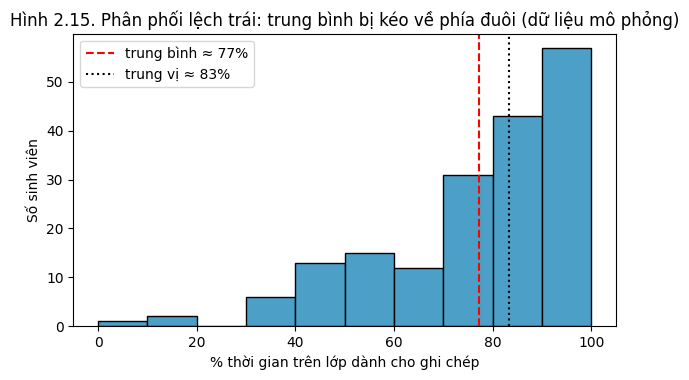

In [30]:
ghi_chep = pd.Series(np.clip(100 * rng.beta(3.2, 1.0, size=180), 0, 100))

plt.figure(figsize=(7, 3.8))
plt.hist(ghi_chep, bins=np.arange(0, 110, 10), color="#4C9FC7", edgecolor="black")
plt.axvline(ghi_chep.mean(), color="red", linestyle="--", label=f"trung bình ≈ {ghi_chep.mean():.0f}%")
plt.axvline(ghi_chep.median(), color="black", linestyle=":", label=f"trung vị ≈ {ghi_chep.median():.0f}%")
plt.xlabel("% thời gian trên lớp dành cho ghi chép")
plt.ylabel("Số sinh viên")
plt.title("Hình 2.15. Phân phối lệch trái: trung bình bị kéo về phía đuôi (dữ liệu mô phỏng)")
plt.legend(loc="upper left")
plt.show()

### 2.11 Mốt *(bổ sung theo đề cương, LLO8.2)*

**Mốt** (mode) là giá trị xuất hiện nhiều lần nhất.

- Với biến phân loại, mốt là nhóm đông nhất. Trong dữ liệu chim cánh cụt, mốt của `species` là Adelie. Đây là thước đo trung tâm duy nhất trong ba thước đo dùng được cho biến danh nghĩa: không thể lấy trung bình hay trung vị của "Adelie, Gentoo, Chinstrap".
- Với biến số rời rạc nhận ít giá trị (số con, số lỗi), mốt là giá trị đếm được nhiều nhất và thường có ý nghĩa.
- Với biến số liên tục, gần như mỗi giá trị chỉ xuất hiện một lần, nên "giá trị xuất hiện nhiều nhất" phụ thuộc vào cách làm tròn khi ghi số. Khi đó người ta nói về **đỉnh** của histogram, như ở mục 2.6 (một đỉnh, hai đỉnh). Đỉnh lại phụ thuộc vào độ rộng khoảng chia (mục 2.3).

Một bộ dữ liệu có thể có nhiều mốt, và mốt không nhất thiết nằm gần trung bình hay trung vị.

In [31]:
print("Mốt của species:", penguins["species"].mode().tolist())
print("Mốt của term (loan50):", loan50["term"].mode().tolist(), "tháng")
print("Mốt của dãy STAT 20:", x.mode().tolist())
print("Mốt của body_mass_g:", penguins["body_mass_g"].mode().tolist(), "g  (chỉ", penguins["body_mass_g"].value_counts().max(), "con trên 333)")

Mốt của species: ['Adelie']
Mốt của term (loan50): [36.0] tháng
Mốt của dãy STAT 20: [7]
Mốt của body_mass_g: [3800.0] g  (chỉ 12 con trên 333)


Dãy STAT 20 có một mốt là 7 (xuất hiện 3 lần), thấp hơn cả trung vị 8 và trung bình 8,45. Mốt của khối lượng chim cánh cụt là 3.800 g nhưng chỉ có 12 con nặng đúng như vậy; con số này nói nhiều về thói quen làm tròn đến 50 g của người đo hơn là về hình dạng phân phối.

> **W02-BS02 [CORE] (bổ sung).**
> 1. Với mỗi biến sau, trung bình, trung vị, mốt, thước đo nào dùng được: `island`; `grade` của loan50 (A–G); số ảnh đính kèm trong `email50`; `interest_rate`?
> 2. Nêu một tình huống mà mốt là con số hữu ích nhất để báo cáo.

<details><summary>Đáp án</summary>

1. `island` (danh nghĩa): chỉ mốt. `grade` (thứ bậc): mốt và trung vị (sắp được thứ tự nên có hạng đứng giữa), không có trung bình. Số ảnh (số rời rạc): cả ba; vì phần lớn thư không có ảnh, mốt là 0. `interest_rate` (liên tục): trung bình và trung vị; mốt ít ý nghĩa, nên nói về đỉnh của histogram.
2. Ví dụ: cửa hàng cần biết cỡ giày bán chạy nhất để nhập hàng; trung bình cỡ giày 40,3 không phải một cỡ có thật.
</details>

---
## Phần 3. Độ phân tán và biểu đồ hộp

### 3.1 Cùng trung tâm, khác độ phân tán

> **W02-EX08 [REASONING].** Hai bộ dữ liệu giả định: A = 7, 8, 9 và B = 1, 8, 15. Cả hai có trung bình = trung vị = 8.
> 1. Bộ nào phân tán hơn?
> 2. Khoảng biến thiên (range = lớn nhất − nhỏ nhất) của mỗi bộ là bao nhiêu?
> 3. Vì sao một con số về trung tâm không đủ để phân biệt A và B?
> 4. Ta muốn một thước đo độ phân tán có tính chất gì?

<details><summary>Đáp án</summary>

B phân tán hơn. Range của A là 2, của B là 14. Hai bộ có cùng trung tâm nên chỉ nhìn trung tâm thì không phân biệt được. Một thước đo phân tán tốt nên bằng 0 khi mọi giá trị bằng nhau, lớn lên khi dữ liệu trải rộng, có cùng đơn vị với dữ liệu để dễ hiểu, và không phụ thuộc hoàn toàn vào hai giá trị ở hai đầu như range.
</details>

### 3.2 Phương sai và độ lệch chuẩn

Ý tưởng: đo xem các quan sát thường cách trung bình bao xa. Lấy độ lệch $x_i - \bar{x}$, bình phương (để âm dương không triệt tiêu nhau), cộng lại rồi chia gần như cho $n$:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2, \qquad s = \sqrt{s^2}.
$$

$s^2$ là **phương sai mẫu**, $s$ là **độ lệch chuẩn mẫu** (standard deviation, SD). Chia cho $n-1$ thay vì $n$ có lý do liên quan đến việc ước lượng tổng thể; Tuần 09 sẽ giải thích, còn bây giờ chỉ cần biết pandas mặc định chia cho $n-1$.

Cách đọc:

- $s$ nhỏ: các giá trị thường nằm gần trung bình. $s$ lớn: dữ liệu trải rộng.
- $s$ có cùng đơn vị với dữ liệu; $s^2$ có đơn vị bình phương.

Ví dụ từ OpenIntro: với 217 sinh viên, số giờ ngủ mỗi đêm có trung bình 6,71 giờ, phương sai 4,11 giờ², SD 2,03 giờ. "Giờ bình phương" rất khó hình dung; "thường lệch khoảng 2 giờ so với trung bình" thì dễ hiểu. Đó là lý do người ta hay báo SD hơn phương sai.

Ô dưới vẽ lại hình của sách bằng dữ liệu **mô phỏng** có cùng cỡ mẫu, trung bình và SD xấp xỉ (sinh viên thường khai số giờ tròn, nên histogram có các cột nhô lên ở số nguyên). Vùng tô màu là khoảng trung bình ± 1 SD.

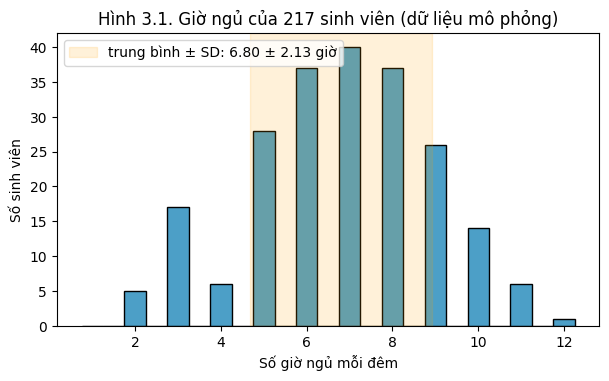

In [32]:
gio_ngu = pd.Series(np.clip(np.round(rng.normal(6.71, 2.03, size=217)), 1, 12))
tb, sd = gio_ngu.mean(), gio_ngu.std()

plt.figure(figsize=(7, 3.8))
plt.hist(gio_ngu, bins=np.arange(0.75, 12.75, 0.5), color="#4C9FC7", edgecolor="black")
plt.axvspan(tb - sd, tb + sd, color="orange", alpha=0.15, label=f"trung bình ± SD: {tb:.2f} ± {sd:.2f} giờ")
plt.xlabel("Số giờ ngủ mỗi đêm")
plt.ylabel("Số sinh viên")
plt.title("Hình 3.1. Giờ ngủ của 217 sinh viên (dữ liệu mô phỏng)")
plt.legend(loc="upper left")
plt.show()

In [33]:
A = pd.Series([7, 8, 9])
B = pd.Series([1, 8, 15])
print("SD của A:", round(A.std(), 2))
print("SD của B:", round(B.std(), 2))

SD của A: 1.0
SD của B: 7.0


### 3.3 Tứ phân vị, IQR, tóm tắt năm số

Cách thứ hai để đo độ phân tán dựa vào thứ tự, giống trung vị.

- $Q_1$ (tứ phân vị thứ nhất): khoảng 25% dữ liệu nằm dưới giá trị này.
- Trung vị: 50%.
- $Q_3$ (tứ phân vị thứ ba): khoảng 75% dữ liệu nằm dưới.
- **Khoảng tứ phân vị**: $\mathrm{IQR} = Q_3 - Q_1$, độ rộng của 50% quan sát ở giữa.

**Tóm tắt năm số** là: nhỏ nhất, $Q_1$, trung vị, $Q_3$, lớn nhất.

Hai cặp thường đi cùng nhau là trung bình với SD, và trung vị với IQR. Đây là thói quen hợp lý chứ không phải luật bắt buộc.

Lưu ý nhỏ: có nhiều quy ước tính tứ phân vị khác nhau (lấy trung vị của nửa dưới, nội suy tuyến tính, ...). Với dữ liệu nhỏ, các quy ước có thể cho kết quả lệch nhau một chút. pandas mặc định dùng nội suy tuyến tính.

In [34]:
khoi_luong = penguins["body_mass_g"]
q1 = khoi_luong.quantile(0.25)
q3 = khoi_luong.quantile(0.75)
print("Tóm tắt năm số:", khoi_luong.min(), q1, khoi_luong.median(), q3, khoi_luong.max())
print("IQR:", q3 - q1)

Tóm tắt năm số: 2700.0 3550.0 4050.0 4775.0 6300.0
IQR: 1225.0


### 3.4 Biểu đồ hộp

Biểu đồ hộp vẽ tóm tắt năm số thành hình: hộp đi từ $Q_1$ đến $Q_3$, vạch trong hộp là trung vị, hai "râu" vươn ra hai phía.

Chỗ hay hiểu sai: **đầu râu không nhất thiết là giá trị nhỏ nhất và lớn nhất**. Với quy ước mặc định của Matplotlib (và của `pandas.plot.box`), ta tính hai "ngưỡng" (fence)

$$
Q_1 - 1{,}5\cdot\mathrm{IQR} \quad\text{và}\quad Q_3 + 1{,}5\cdot\mathrm{IQR}.
$$

Râu vươn tới quan sát xa nhất *còn nằm trong* ngưỡng. Các quan sát ngoài ngưỡng được vẽ riêng thành chấm và thường được gọi là ngoại lai tiềm năng.

Hình dưới vẽ lại hình giải phẫu biểu đồ hộp của OpenIntro Statistics 4e, dùng số giờ tự học mỗi tuần của 193 sinh viên (dữ liệu `gpa_study_hours`). Bên trái là từng quan sát; bên phải là biểu đồ hộp tương ứng.

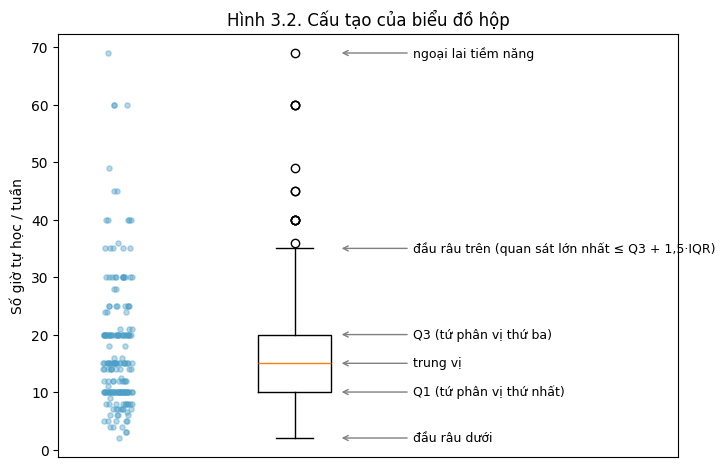

Q1 = 10.0, trung vị = 15.0, Q3 = 20.0, IQR = 10.0, ngưỡng trên = 35.0
Đầu râu trên dừng ở: 35.0   Các quan sát vẽ riêng: [36, 40, 45, 49, 60, 69]


In [35]:
gio_hoc = gpa_hoc["study_hours"]
q1, trung_vi, q3 = gio_hoc.quantile([0.25, 0.5, 0.75])
iqr = q3 - q1
hang_rao_tren = q3 + 1.5 * iqr
rau_tren = gio_hoc[gio_hoc <= hang_rao_tren].max()
rau_duoi = gio_hoc[gio_hoc >= q1 - 1.5 * iqr].min()
ngoai_lai = gio_hoc[gio_hoc > hang_rao_tren]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(rng.uniform(-0.05, 0.05, len(gio_hoc)), gio_hoc, s=14, alpha=0.4, color="#4C9FC7")
ax.boxplot(gio_hoc, positions=[0.6], widths=0.25)
chu_thich = [(ngoai_lai.max(), "ngoại lai tiềm năng"), (rau_tren, "đầu râu trên (quan sát lớn nhất ≤ Q3 + 1,5·IQR)"),
             (q3, "Q3 (tứ phân vị thứ ba)"), (trung_vi, "trung vị"), (q1, "Q1 (tứ phân vị thứ nhất)"),
             (rau_duoi, "đầu râu dưới")]
for y, nhan in chu_thich:
    ax.annotate(nhan, xy=(0.75, y), xytext=(1.0, y), va="center", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlim(-0.2, 1.9)
ax.set_xticks([])
ax.set_ylabel("Số giờ tự học / tuần")
ax.set_title("Hình 3.2. Cấu tạo của biểu đồ hộp")
plt.show()

print(f"Q1 = {q1}, trung vị = {trung_vi}, Q3 = {q3}, IQR = {iqr}, ngưỡng trên = {hang_rao_tren}")
print("Đầu râu trên dừng ở:", rau_tren, "  Các quan sát vẽ riêng:", sorted(int(v) for v in ngoai_lai.unique()))

Râu trên dừng ở 35 giờ, quan sát lớn nhất còn trong ngưỡng 35, chứ không phải ở giá trị lớn nhất 69. Các sinh viên khai hơn 35 giờ được vẽ thành chấm riêng.

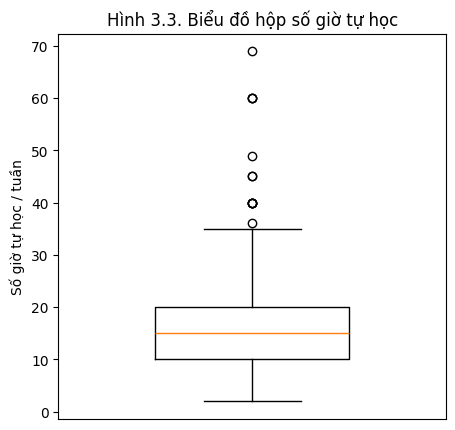

In [36]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.boxplot(gio_hoc, widths=0.5)
ax.set_xticks([])
ax.set_ylabel("Số giờ tự học / tuần")
ax.set_title("Hình 3.3. Biểu đồ hộp số giờ tự học")
plt.show()

> **W02-EX09 [REASONING] — Biểu đồ hộp cho thấy gì, che mất gì?** Nhìn Hình 3.3:
> 1. Chỉ ra trung vị và vùng chứa 50% quan sát ở giữa.
> 2. Biểu đồ hộp giúp đọc trung tâm và độ phân tán thế nào?
> 3. Nó có thể che mất những đặc điểm hình dạng nào?
> 4. Vì sao nên xem thêm histogram hoặc dot plot?

<details><summary>Đáp án</summary>

Trung vị là vạch trong hộp; hộp từ $Q_1$ đến $Q_3$ chứa 50% quan sát ở giữa. Biểu đồ hộp rất tiện để so nhanh trung tâm và độ phân tán giữa nhiều nhóm. Nhưng nó nén mạnh: không cho thấy số đỉnh, khoảng trống, các cụm, hay chi tiết ở đuôi. Vì vậy nên đi kèm histogram hoặc dot plot. Tóm tắt bằng số cộng với đồ thị thường mạnh hơn từng thứ đứng riêng.
</details>

<details><summary>Đáp án bổ sung: so với histogram</summary>

Ô dưới đặt Hình 3.3 cạnh histogram của cùng dữ liệu. Histogram cho thấy các số giờ tròn 10, 15, 20, 30 được khai rất nhiều và có một khoảng trống giữa 50 và 60 giờ; biểu đồ hộp không thể hiện được những điều đó.
</details>

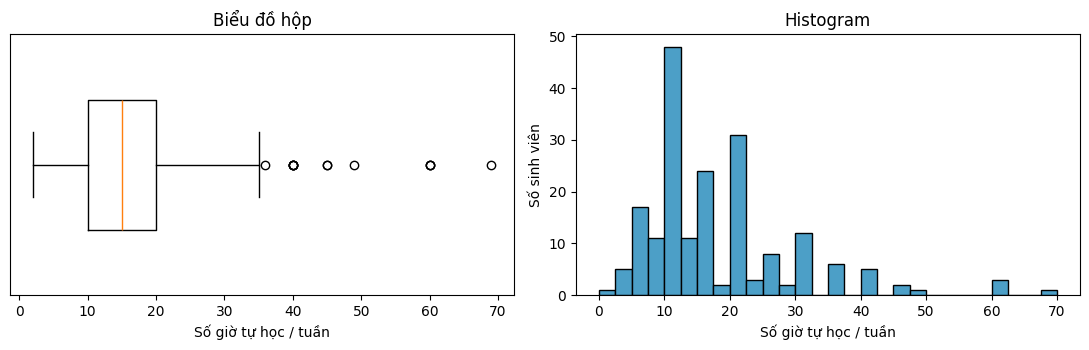

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].boxplot(gio_hoc, widths=0.5, **NGANG)
axes[0].set_yticks([])
axes[0].set_xlabel("Số giờ tự học / tuần")
axes[0].set_title("Biểu đồ hộp")
axes[1].hist(gio_hoc, bins=np.arange(0, 72, 2.5), color="#4C9FC7", edgecolor="black")
axes[1].set_xlabel("Số giờ tự học / tuần")
axes[1].set_ylabel("Số sinh viên")
axes[1].set_title("Histogram")
plt.tight_layout()
plt.show()

### 3.5 Biểu đồ hộp che mất điều gì?

> **W02-Q05 [CORE] — Một tóm tắt không kể hết câu chuyện.** Hai phân phối có thể có cùng trung vị và IQR nhưng hình dạng rất khác nhau không?

Ô dưới xây hai bộ dữ liệu mô phỏng: bộ 1 có một đỉnh, bộ 2 có hai cụm tách rời. Hãy đoán biểu đồ hộp của chúng trông thế nào trước khi chạy.

Bộ 1: trung vị = 50.3, IQR = 14.1
Bộ 2: trung vị = 50.3, IQR = 14.1


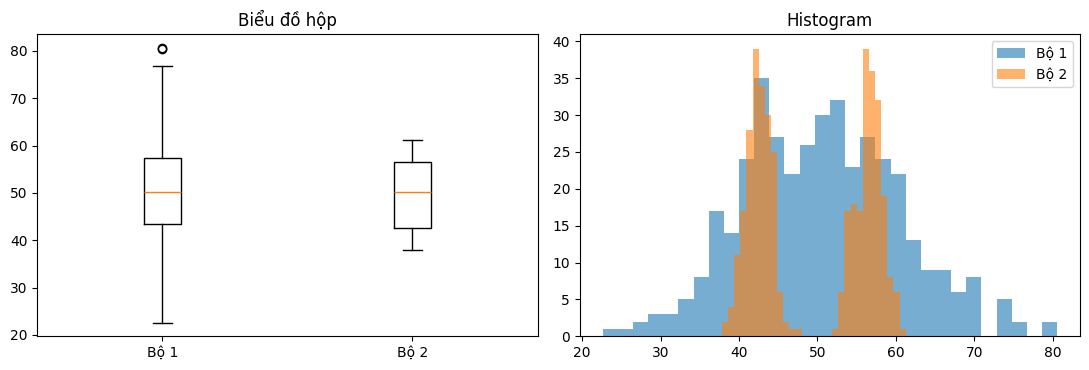

In [38]:
mot_dinh = rng.normal(50, 10, size=400)
hai_cum = np.concatenate([rng.normal(38, 3, size=200), rng.normal(62, 3, size=200)])

# Dịch và co giãn bộ 2 để có đúng trung vị và IQR như bộ 1
def trung_vi_va_iqr(v):
    return np.median(v), np.percentile(v, 75) - np.percentile(v, 25)

m1, i1 = trung_vi_va_iqr(mot_dinh)
m2, i2 = trung_vi_va_iqr(hai_cum)
hai_cum = (hai_cum - m2) * (i1 / i2) + m1

print("Bộ 1: trung vị = %.1f, IQR = %.1f" % trung_vi_va_iqr(mot_dinh))
print("Bộ 2: trung vị = %.1f, IQR = %.1f" % trung_vi_va_iqr(hai_cum))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].boxplot([mot_dinh, hai_cum])
axes[0].set_xticks([1, 2], ["Bộ 1", "Bộ 2"])
axes[0].set_title("Biểu đồ hộp")
axes[1].hist(mot_dinh, bins=30, alpha=0.6, label="Bộ 1")
axes[1].hist(hai_cum, bins=30, alpha=0.6, label="Bộ 2")
axes[1].set_title("Histogram")
axes[1].legend()
plt.tight_layout()
plt.show()

Hai hộp có cùng vạch giữa và cùng chiều cao; chỉ râu và vài chấm ngoài là khác một chút. Nhìn riêng biểu đồ hộp, không ai đoán được hai bộ khác nhau đến mức nào. Histogram thì cho thấy bộ 2 gồm hai cụm, và gần như không có quan sát nào ở đúng vị trí trung vị. Nếu đây là dữ liệu thật, hai cụm thường là dấu hiệu của hai nhóm khác nhau bị trộn lẫn.

---
## Phần 4. Phản biện và giải quyết vấn đề

Từ đây không chỉ tính theo công thức nữa. Ta chọn tóm tắt, phản biện kết luận của người khác, và tự xây phản ví dụ.

### 4.1 Giá trị cực đoan không tác động đều lên mọi tóm tắt

OpenIntro minh họa ý này bằng cách đẩy một thu nhập lên 10 triệu USD. Ta làm lại với `loan50`.

In [39]:
def bon_tom_tat(s):
    return pd.Series({
        "trung bình": s.mean(),
        "SD": s.std(),
        "trung vị": s.median(),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
    })

thu_nhap_goc = loan50["annual_income"]
thu_nhap_sua = thu_nhap_goc.copy()
thu_nhap_sua[thu_nhap_sua.idxmax()] = 10_000_000     # người thu nhập cao nhất thành 10 triệu USD

so_sanh = pd.DataFrame({"gốc": bon_tom_tat(thu_nhap_goc), "sau khi sửa": bon_tom_tat(thu_nhap_sua)})
so_sanh["gấp bao nhiêu lần"] = so_sanh["sau khi sửa"] / so_sanh["gốc"]
so_sanh.round(1)

,gốc,sau khi sửa,gấp bao nhiêu lần
trung bình,86170.0,279670.0,3.2
SD,57566.5,1403474.2,24.4
trung vị,74000.0,74000.0,1.0
IQR,43750.0,43750.0,1.0


Hình dưới vẽ lại ý của OpenIntro dưới dạng tương tác: mỗi chấm là một người vay, thanh trượt đẩy thu nhập của người cao nhất lên dần tới 10 triệu USD. Để ý đường trung bình chạy theo, còn đường trung vị đứng yên.

In [40]:
jitter = rng.uniform(0, 1, len(thu_nhap_goc))
vi_tri_max = thu_nhap_goc.idxmax()
cac_muc_max = [thu_nhap_goc.max(), 500_000, 1_000_000, 2_500_000, 5_000_000, 10_000_000]

fig = go.Figure()
for gia_tri in cac_muc_max:
    du_lieu = thu_nhap_goc.copy()
    du_lieu[vi_tri_max] = gia_tri
    tb, tv = du_lieu.mean() / 1000, du_lieu.median() / 1000
    hien = gia_tri == cac_muc_max[0]
    fig.add_trace(go.Scatter(x=du_lieu / 1000, y=jitter, mode="markers", visible=hien, name="người vay",
                             marker=dict(size=8, color="#4C9FC7", opacity=0.7),
                             hovertemplate="%{x:,.0f} nghìn USD<extra></extra>"))
    fig.add_trace(go.Scatter(x=[tb, tb], y=[-0.05, 1.05], mode="lines", visible=hien, name=f"trung bình = {tb:,.1f}",
                             line=dict(color="red", dash="dash")))
    fig.add_trace(go.Scatter(x=[tv, tv], y=[-0.05, 1.05], mode="lines", visible=hien, name=f"trung vị = {tv:,.1f}",
                             line=dict(color="black", dash="dot")))
buoc = [dict(method="update", label=f"{g / 1000:,.0f}",
             args=[{"visible": [k == i for k in range(len(cac_muc_max)) for _ in range(3)]}])
        for i, g in enumerate(cac_muc_max)]
fig.update_layout(
    title="Hình 4.1. Một giá trị cực đoan kéo trung bình, không kéo trung vị",
    xaxis_title="Thu nhập năm (nghìn USD)", yaxis=dict(visible=False), width=850, height=420,
    legend=dict(orientation="h", y=1.08),
    sliders=[dict(active=0, steps=buoc, pad={"t": 50},
                  currentvalue={"prefix": "Thu nhập của người cao nhất (nghìn USD): "})])
fig.show()

Chỉ một người trong 50 thay đổi. Trung bình tăng khoảng ba lần, SD tăng khoảng 24 lần, còn trung vị và IQR không nhúc nhích. Tính chất này gọi là **robustness**, và ta nói trung vị và IQR là các thống kê **robust** trước giá trị cực đoan, trung bình và SD thì không.

Robust không có nghĩa là "luôn tốt hơn". Nó chỉ là một tính chất cần biết khi chọn tóm tắt.

### 4.2 Chọn tóm tắt theo mục đích

Quy tắc kinh nghiệm:

- phân phối gần đối xứng, không có giá trị cực đoan chi phối: trung bình và SD thường dễ hiểu và đủ dùng;
- phân phối lệch mạnh hoặc có giá trị cực đoan: trung vị và IQR thường mô tả "điển hình" trung thực hơn.

Nhưng mục đích mới là thứ quyết định. Nếu cần tổng hoặc bình quân trên toàn bộ đơn vị (tổng doanh thu, tổng thời gian chờ), trung bình chính là đại lượng cần, dù dữ liệu lệch. Nếu cần mô tả "một người điển hình", trung vị thường hợp hơn.

> **W02-CH02 [CHALLENGE] — Khi một con số đúng nhưng gây hiểu nhầm.** Dùng dãy STAT 20: 8, 11, 7, 7, 8, 11, 9, 6, 10, 7, 9, rồi thay 6 bằng −200.
> 1. So sánh trung bình, trung vị, SD, IQR trước và sau.
> 2. Tóm tắt nào robust hơn?
> 3. Một báo cáo chỉ ghi "trung bình = −10,27" đã che giấu điều gì?
> 4. Đề xuất một cặp tóm tắt bằng số và một đồ thị.
> 5. Phản biện: "Trung bình âm chứng tỏ phần lớn dữ liệu là số âm."

In [41]:
pd.DataFrame({"gốc": bon_tom_tat(x), "thay 6 bằng −200": bon_tom_tat(x_loi)}).round(3)

,gốc,thay 6 bằng −200
trung bình,8.455,-10.273
SD,1.695,62.943
trung vị,8.000,8.000
IQR,2.500,2.500


<details><summary>Đáp án</summary>

1. và 2. Trung bình từ 8,455 xuống −10,273; SD từ 1,695 lên 62,943; trung vị giữ 8; IQR giữ 2,5. Trung vị và IQR robust hơn nhiều.
3. Nó che việc 10 trên 11 quan sát vẫn nằm trong khoảng 7 đến 11. Người đọc không có cách nào biết điều đó.
4. Với mục đích mô tả giá trị điển hình: trung vị và IQR, kèm dot plot hoặc biểu đồ hộp để điểm −200 hiện ra rõ ràng (và để ai đó kiểm tra xem nó có phải lỗi nhập không).
5. Sai. Chỉ có một giá trị âm. Trung bình âm vì giá trị đó có độ lớn rất lớn, đủ để kéo cả tổng xuống dưới 0.
</details>

> **W02-CH01 [CHALLENGE] — Chọn mẫu số trong bảng lỗi kỹ thuật.** Một đợt kiểm thử (tình huống giả định) ghi nhận:

In [42]:
bang_loi = pd.DataFrame(
    {"Không lỗi": [72, 150], "Lỗi tạm thời": [18, 30], "Lỗi nghiêm trọng": [10, 20]},
    index=["A", "B"],
)
bang_loi.index.name = "Loại thiết bị"
bang_loi_day_du = bang_loi.copy()
bang_loi_day_du["Tổng"] = bang_loi_day_du.sum(axis=1)
bang_loi_day_du.loc["Tổng"] = bang_loi_day_du.sum()
bang_loi_day_du

,Không lỗi,Lỗi tạm thời,Lỗi nghiêm trọng,Tổng
Loại thiết bị,,,,
A,72,18,10,100
B,150,30,20,200
Tổng,222,48,30,300


> Không có công thức cho sẵn; tự chọn mẫu số.
> 1. Trong số thiết bị A, bao nhiêu phần gặp lỗi nghiêm trọng?
> 2. Trong số mọi lỗi nghiêm trọng, bao nhiêu phần thuộc loại A?
> 3. Trong toàn bộ 300 thiết bị, bao nhiêu phần vừa là A vừa lỗi nghiêm trọng?
> 4. Một kỹ sư nói: "B nguy hiểm gấp đôi A vì có 20 lỗi nghiêm trọng so với 10." Phản biện.

<details><summary>Đáp án</summary>

1. 10/100 = 10%.
2. 10/30 ≈ 33,3%.
3. 10/300 ≈ 3,3%.
4. Kỹ sư so số đếm thô giữa hai nhóm có kích thước khác nhau (100 và 200 thiết bị). Tính trong từng loại, tỉ lệ lỗi nghiêm trọng của A là 10/100 = 10% và của B là 20/200 = 10%. Bảng này không ủng hộ nhận định B có tỉ lệ lỗi gấp đôi A.
</details>

> **W02-CH03 [DESIGN] — Chứng minh hoặc bác bỏ.** "Nếu một bộ dữ liệu có trung bình bằng trung vị thì phân phối phải đối xứng." Nếu bác bỏ, hãy tự xây một bộ 5 giá trị có trung bình bằng trung vị nhưng không đối xứng, và nói rõ vì sao nó không đối xứng. Phải kiểm tra được bằng số.

Viết bộ dữ liệu của bạn vào ô dưới và chạy.

In [43]:
bo_cua_ban = pd.Series([-4, -1, 0, 2, 3])   # thay bằng bộ số của bạn
print("Trung bình:", bo_cua_ban.mean(), "  Trung vị:", bo_cua_ban.median())

Trung bình: 0.0   Trung vị: 0.0


<details><summary>Đáp án</summary>

Mệnh đề sai. Phản ví dụ −4, −1, 0, 2, 3 (đang có sẵn trong ô trên): tổng bằng 0 nên trung bình bằng 0, và trung vị cũng bằng 0. Nhưng dữ liệu không đối xứng quanh 0: phía âm có −4 và −1, phía dương có 2 và 3; −4 không có "đối tác" +4. Trung bình bằng trung vị không đủ để suy ra hình dạng.
</details>

> **W02-CH04 [DESIGN] — Cùng trung bình và SD, khác hẳn hình dạng.** Bác bỏ mệnh đề "Hai bộ dữ liệu có cùng trung bình và cùng SD thì về cơ bản giống nhau." Xây hai bộ có cùng số quan sát, cùng trung bình, cùng SD mẫu, nhưng phân bố giá trị khác rõ. Không được chỉ đổi thứ tự phần tử.

In [44]:
bo_A = pd.Series([-1, -1, -1, 1, 1, 1])     # thay bằng hai bộ của bạn
bo_B = pd.Series([-2, 0, 0, 0, 1, 1])
for ten, bo in [("A", bo_A), ("B", bo_B)]:
    print(f"Bộ {ten}: n = {len(bo)}, trung bình = {bo.mean():.3f}, SD = {bo.std():.3f}, các giá trị = {sorted(bo)}")

Bộ A: n = 6, trung bình = 0.000, SD = 1.095, các giá trị = [-1, -1, -1, 1, 1, 1]
Bộ B: n = 6, trung bình = 0.000, SD = 1.095, các giá trị = [-2, 0, 0, 0, 1, 1]


<details><summary>Đáp án</summary>

Ví dụ trong ô trên. Cả hai bộ có $\bar{x} = 0$ và $\sum(x_i - \bar{x})^2 = 6$, nên $s = \sqrt{6/5} \approx 1{,}095$. Bộ A đối xứng và chỉ có hai giá trị −1 và 1. Bộ B dồn ba quan sát vào 0 và có một đuôi trái tới −2. Trung bình và SD không xác định được hình dạng; chúng làm mất thông tin về số đỉnh, độ lệch, và các giá trị cụ thể.
</details>

> **W02-CH05 [CHALLENGE] — Đổi thang đo thì tóm tắt đổi thế nào?** Cho dữ liệu $X = (x_1, \dots, x_n)$ và $Y = aX + b$ với $a \ne 0$ (ví dụ đổi độ C sang độ F: $a = 1{,}8$, $b = 32$). Không tra công thức, hãy suy ra $Y$ có trung bình, trung vị, SD mẫu, IQR bằng bao nhiêu theo các đại lượng của $X$. Sau đó: vì sao SD và IQR dùng $|a|$ chứ không phải $a$? Nếu $a < 0$ thì thứ tự các quan sát ra sao?

Hãy suy luận trước. Ô `COMPUTE` ở cuối Phần 5 sẽ kiểm chứng.

<details><summary>Đáp án</summary>

- Trung bình: $\bar{y} = \frac{1}{n}\sum (a x_i + b) = a\bar{x} + b$.
- Trung vị: phép biến đổi $y = ax + b$ giữ nguyên thứ tự khi $a > 0$ và đảo ngược thứ tự khi $a < 0$. Trong cả hai trường hợp giá trị đứng giữa vẫn đứng giữa, nên $\mathrm{Med}(Y) = a\,\mathrm{Med}(X) + b$.
- SD: $y_i - \bar{y} = a(x_i - \bar{x})$, nên $s_Y^2 = a^2 s_X^2$ và $s_Y = |a|\, s_X$.
- IQR: khi $a > 0$, $Q_1$ và $Q_3$ biến đổi như trung vị nên $\mathrm{IQR}_Y = a \cdot \mathrm{IQR}_X$. Khi $a < 0$, thứ tự đảo nên $Q_1$ và $Q_3$ đổi chỗ cho nhau, và khoảng cách vẫn là $|a| \cdot \mathrm{IQR}_X$.

Độ phân tán là một khoảng cách nên không thể âm; vì thế dùng $|a|$. Hằng số $b$ chỉ dịch mọi thứ sang ngang, không làm dữ liệu trải rộng hơn, nên không xuất hiện trong SD và IQR.
</details>

> **W02-CH06 [DESIGN] — Dữ liệu mà trung bình mô tả "điển hình" rất tệ.** Xây một bộ 7 giá trị sao cho ít nhất 5 giá trị nằm trong đoạn [9, 11] nhưng trung bình cả bộ nhỏ hơn 0. Tính trung bình và trung vị, giải thích vì sao trung bình là mô tả điển hình kém, và đề xuất cách tóm tắt tốt hơn.

In [45]:
bo_7_gia_tri = pd.Series([9, 9, 10, 10, 10, 11, -100])   # thay bằng bộ của bạn
trong_doan = bo_7_gia_tri.between(9, 11).sum()
print("Số giá trị trong [9, 11]:", trong_doan)
print("Trung bình:", round(bo_7_gia_tri.mean(), 2), "  Trung vị:", bo_7_gia_tri.median())

Số giá trị trong [9, 11]: 6
Trung bình: -5.86   Trung vị: 10.0


<details><summary>Đáp án</summary>

Ví dụ 9, 9, 10, 10, 10, 11, −100: có 6/7 giá trị trong [9, 11], trung bình $-41/7 \approx -5{,}86$, trung vị 10. Một quan sát cực đoan kéo trung bình ra khỏi cụm chính, tới chỗ không có quan sát nào. Để mô tả giá trị điển hình, dùng trung vị và IQR kèm dot plot; đồng thời kiểm tra xem −100 là gì.
</details>

### 4.3 Bài tập cuối chương (chuyển thể từ OpenIntro)

> **W02-EX10 [REASONING] — Bài thi bù** *(OpenIntro Statistics 4e, Chương 2, bài "Make-up exam").* Lớp có 25 sinh viên, 24 bạn thi cùng ngày với trung bình 74 và SD mẫu 8,9. Bạn còn lại thi bù được 64 điểm.
> 1. Trung bình mới tăng hay giảm?
> 2. Tính trung bình mới.
> 3. SD mới tăng hay giảm một chút? Giải thích bằng trực giác.

<details><summary>Đáp án</summary>

1. Giảm, vì 64 thấp hơn 74.
2. $\bar{x}_{\text{mới}} = \dfrac{24 \cdot 74 + 64}{25} = 73{,}6$.
3. Tăng nhẹ, vì 64 cách trung bình khoảng 10 điểm, xa hơn một chút so với mức lệch điển hình 8,9. Tính cụ thể: tổng bình phương độ lệch của 24 bạn quanh 74 là $23 \cdot 8{,}9^2 = 1821{,}83$. Khi đổi tâm sang 73,6, tổng này tăng thêm $24(74 - 73{,}6)^2 = 3{,}84$ (đúng đẳng thức ở mục 2.9). Cộng thêm bạn thi bù $(64 - 73{,}6)^2 = 92{,}16$. Vậy $s_{\text{mới}} = \sqrt{(1821{,}83 + 3{,}84 + 92{,}16)/24} \approx 8{,}94$. SD chỉ tăng nhẹ vì một điểm mới chỉ chiếm 1/25 lớp.
</details>

> **W02-EX11 [REASONING] — Điểm thi và biểu đồ hộp** *(OpenIntro Statistics 4e, Chương 2, bài "Stats scores").* 20 điểm thi đã sắp tăng dần: 57, 66, 69, 71, 72, 73, 74, 77, 78, 78, 79, 79, 81, 81, 82, 83, 83, 88, 89, 94. Tóm tắt năm số (theo quy ước của sách): 57; 72,5; 78,5; 82,5; 94.
> 1. Tính IQR.
> 2. Tính hai ngưỡng 1,5·IQR.
> 3. Điểm nào là ngoại lai tiềm năng?
> 4. Râu dưới dừng ở 57 hay 66? Vì sao?

Tứ phân vị theo pandas (nội suy tuyến tính): [72.75, 78.5, 82.25]


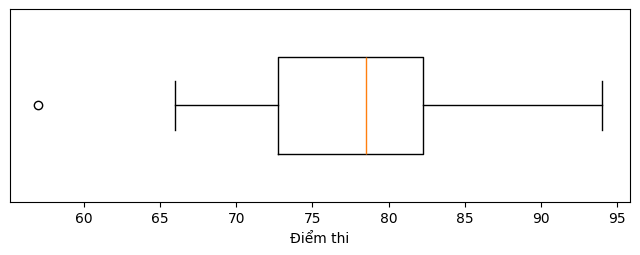

In [46]:
diem = pd.Series([57, 66, 69, 71, 72, 73, 74, 77, 78, 78, 79, 79, 81, 81, 82, 83, 83, 88, 89, 94])
print("Tứ phân vị theo pandas (nội suy tuyến tính):", diem.quantile([0.25, 0.5, 0.75]).tolist())

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.boxplot(diem, widths=0.5, **NGANG)
ax.set_xlabel("Điểm thi")
ax.set_yticks([])
plt.show()

<details><summary>Đáp án</summary>

Theo quy ước của sách: $\mathrm{IQR} = 82{,}5 - 72{,}5 = 10$. Ngưỡng dưới $72{,}5 - 15 = 57{,}5$, ngưỡng trên $82{,}5 + 15 = 97{,}5$. Điểm 57 nằm dưới ngưỡng dưới nên là ngoại lai tiềm năng; 94 không vượt ngưỡng trên. Râu dưới dừng ở 66, quan sát nhỏ nhất còn trong ngưỡng, và 57 được vẽ thành chấm riêng.

pandas cho $Q_1 = 72{,}75$ và $Q_3 = 82{,}25$ vì dùng quy ước nội suy khác, nên IQR = 9,5 và ngưỡng dưới là 58,5. Kết luận không đổi: 57 vẫn là điểm ngoại lai, râu vẫn dừng ở 66, như hình trên cho thấy.
</details>

> **W02-EX12 [REASONING] — Quan điểm về nhập cư** *(IMS 2e, Chương 4, bài "Views on immigration").* 910 người được hỏi nên xử lý thế nào với người lao động nhập cư không giấy tờ, phân theo khuynh hướng chính trị tự nhận.

In [47]:
nhap_cu = pd.DataFrame(
    {"Conservative": [57, 121, 179, 15],
     "Liberal":      [101, 28, 45, 1],
     "Moderate":     [120, 113, 126, 4]},
    index=["Apply for citizenship", "Guest worker", "Leave the country", "Not sure"],
)
nhap_cu

,Conservative,Liberal,Moderate
Apply for citizenship,57,101,120
Guest worker,121,28,113
Leave the country,179,45,126
Not sure,15,1,4


> 1. Tỉ lệ Conservative trong toàn mẫu?
> 2. Tỉ lệ chọn "Apply for citizenship" trong toàn mẫu?
> 3. Trong từng nhóm khuynh hướng, tỉ lệ chọn "Apply for citizenship" là bao nhiêu?
> 4. Các tỉ lệ có điều kiện cho thấy mối liên hệ gì?
>
> Tính bằng tay trước. Ô dưới để kiểm tra câu 3.

In [48]:
(nhap_cu / nhap_cu.sum()).round(3)

,Conservative,Liberal,Moderate
Apply for citizenship,0.153,0.577,0.331
Guest worker,0.325,0.160,0.311
Leave the country,0.481,0.257,0.347
Not sure,0.040,0.006,0.011


<details><summary>Đáp án</summary>

1. 372/910 ≈ 40,9%.
2. 278/910 ≈ 30,5%.
3. Conservative 57/372 ≈ 15,3%; Liberal 101/175 ≈ 57,7%; Moderate 120/363 ≈ 33,1%. (Mỗi cột của bảng trên cộng lại bằng 1.)
4. Tỉ lệ chọn "Apply for citizenship" khác nhau rõ giữa các nhóm, nên trong mẫu này khuynh hướng chính trị và câu trả lời có liên hệ với nhau. Bảng không cho phép nói khuynh hướng chính trị *gây ra* quan điểm.
</details>

> **W02-EX13 [REASONING] — Chọn tóm tắt theo hình dạng** *(IMS 2e, Chương 5, bài 15).* Với mỗi biến, đoán hình dạng phân phối và chọn giữa (trung bình, SD) và (trung vị, IQR):
> 1. số thú cưng trong một hộ gia đình;
> 2. chiều cao của nam giới trưởng thành;
> 3. điểm của một bài thi rất dễ.

<details><summary>Đáp án</summary>

1. Phần lớn hộ có 0, 1 hoặc 2 con, một số ít hộ nuôi rất nhiều: lệch phải. Trung vị và IQR thường hữu ích hơn.
2. Gần đối xứng, không có giá trị cực đoan chi phối: trung bình và SD hợp lý.
3. Nhiều người đạt điểm cao sát trần, một số ít điểm thấp tạo đuôi bên trái: lệch trái. Trung vị và IQR thường robust hơn.

Đây là quy tắc kinh nghiệm dựa trên hình dạng, không phải luật.
</details>

### 4.4 Tình huống tổng hợp: Palmer penguins

> **W02-CASE01 [CHALLENGE].** Dùng bảng loài × đảo ở mục 1.1 và thông tin về `body_mass_g` (STAT 20 báo cáo trung vị 4.050 g, IQR 1.225 g, phân phối lệch phải).
> 1. `species`, `island`, `body_mass_g` là loại biến gì?
> 2. Chọn tóm tắt mở đầu cho từng biến và cho cặp (`species`, `island`).
> 3. Diễn giải ô 55.
> 4. Tỉ lệ Adelie ở Dream trên toàn bộ 333 con?
> 5. Tỉ lệ Adelie sống ở Dream, trong số các con Adelie?
> 6. Tỉ lệ Adelie, trong số các con ở Dream?
> 7. Đánh giá mối liên hệ giữa loài và đảo.
> 8. Viết mô tả ngắn cho `body_mass_g` từ các thông tin đã cho.
> 9. Trung bình hay trung vị hợp hơn cho "khối lượng điển hình"?
> 10. SD hay IQR hợp hơn cho độ phân tán trong bối cảnh này?
> 11. `pd.crosstab(..., normalize="index")` trả lời câu hỏi nào?
> 12. Phản biện: "Loài chim cánh cụt quyết định hòn đảo nó sống."

In [49]:
print("Câu 4:", round(55 / 333, 3))
print("Câu 5:", round(55 / 146, 3))
print("Câu 6:", round(55 / 123, 3))
print()
print("Kiểm tra câu 8–10 trên dữ liệu:")
print("  trung vị =", penguins["body_mass_g"].median(),
      "  IQR =", penguins["body_mass_g"].quantile(0.75) - penguins["body_mass_g"].quantile(0.25),
      "  trung bình =", round(penguins["body_mass_g"].mean(), 1))

Câu 4: 0.165
Câu 5: 0.377
Câu 6: 0.447

Kiểm tra câu 8–10 trên dữ liệu:
  trung vị = 4050.0   IQR = 1225.0   trung bình = 4207.1


<details><summary>Đáp án</summary>

1. `species`, `island`: phân loại danh nghĩa. `body_mass_g`: biến số liên tục.
2. `species`, `island`: bảng đếm hoặc tỉ lệ, biểu đồ cột. Cặp (`species`, `island`): bảng liên hợp và tỉ lệ có điều kiện. `body_mass_g`: histogram, rồi trung tâm và độ phân tán.
3. Có 55 con Adelie được ghi nhận ở đảo Dream.
4. 55/333 ≈ 16,5%.
5. 55/146 ≈ 37,7%.
6. 55/123 ≈ 44,7%.
7. Liên hệ rất mạnh: phân phối đảo thay đổi hoàn toàn theo loài (Gentoo chỉ ở Biscoe, Chinstrap chỉ ở Dream).
8. Khối lượng phân phối lệch phải; con điển hình nặng khoảng 4.050 g; 50% ở giữa trải trong một khoảng rộng khoảng 1.225 g.
9. Trung vị là lựa chọn robust hợp lý cho "điển hình". Trung bình (khoảng 4.207 g, cao hơn trung vị như dự đoán với phân phối lệch phải) không vì thế mà sai.
10. IQR, đi cặp với trung vị.
11. Mỗi hàng cộng lại bằng 1: trong mỗi loài, các con phân bố trên các đảo ra sao.
12. Đây là khẳng định nhân quả; bảng chỉ cho thấy mối liên hệ. Loài và nơi sống có thể cùng phản ánh lịch sử di cư, thức ăn, địa hình. Bảng không cho biết gì về cơ chế.
</details>

---
## Phần 5. Python/pandas để kiểm chứng

Mục tiêu ở đây là dùng vài lệnh ngắn để kiểm tra một lập luận, không phải học nhiều cú pháp. Trước mỗi ô, hãy đoán kết quả.

**Dự đoán:** trong ba lệnh dưới, lệnh nào cho số đếm, lệnh nào cho tỉ lệ? `margins=True` thêm những tổng nào?

In [50]:
print(penguins["species"].value_counts(), "\n")
print(penguins["species"].value_counts(normalize=True).round(3), "\n")
print(pd.crosstab(penguins["species"], penguins["island"], margins=True))

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64 

species
Adelie       0.438
Gentoo       0.357
Chinstrap    0.204
Name: proportion, dtype: float64 

island     Biscoe  Dream  Torgersen  All
species                                 
Adelie         44     55         47  146
Chinstrap       0     68          0   68
Gentoo        119      0          0  119
All           163    123         47  333


`value_counts()` đếm số con mỗi loài. `normalize=True` chia các số đếm đó cho tổng số quan sát hợp lệ để thành tỉ lệ. `crosstab(..., margins=True)` tạo bảng liên hợp và thêm tổng hàng, tổng cột, tổng chung (hàng và cột `All`).

Đọc kết quả của code cũng như đọc bảng bằng tay: mỗi con số đang dùng mẫu số nào và trả lời câu hỏi nào.

> **W02-PY01 [COMPUTE] — Mẫu số nằm ở đâu trong code?**
> 1. Bảng nào trả lời "trong mỗi loài, các con ở những đảo nào"?
> 2. Bảng nào trả lời "trên mỗi đảo, có những loài nào"?
> 3. Trong mỗi bảng, chiều nào cộng lại bằng 1?
> 4. Không mở tài liệu: từ câu hỏi thống kê, hãy suy ra `"index"` và `"columns"` nghĩa là gì.

In [51]:
row_prop = pd.crosstab(penguins["species"], penguins["island"], normalize="index")
col_prop = pd.crosstab(penguins["species"], penguins["island"], normalize="columns")
print("normalize='index':")
print(row_prop.round(3))
print("\nnormalize='columns':")
print(col_prop.round(3))

normalize='index':
island     Biscoe  Dream  Torgersen
species                            
Adelie      0.301  0.377      0.322
Chinstrap   0.000  1.000      0.000
Gentoo      1.000  0.000      0.000

normalize='columns':
island     Biscoe  Dream  Torgersen
species                            
Adelie       0.27  0.447        1.0
Chinstrap    0.00  0.553        0.0
Gentoo       0.73  0.000        0.0


<details><summary>Đáp án</summary>

`normalize="index"` chia mỗi hàng cho tổng hàng, nên mỗi hàng cộng lại bằng 1: đó là phân phối đảo trong từng loài (câu 1). `normalize="columns"` chia mỗi cột cho tổng cột, mỗi cột cộng lại bằng 1: phân phối loài trên từng đảo (câu 2). `"index"` chỉ các hàng (nhãn hàng của DataFrame gọi là index), `"columns"` chỉ các cột.
</details>

> **W02-PY05 [COMPUTE] — Kiểm chứng phép đổi thang đo.** Với $X$ là dãy STAT 20 và $Y = 3X + 5$, từ bốn tóm tắt của $X$ (đã tính ở mục 4.2), hãy dự đoán bốn tóm tắt của $Y$ theo kết quả CH05. Rồi chạy ô dưới.

In [52]:
X = pd.Series([8, 11, 7, 7, 8, 11, 9, 6, 10, 7, 9])
Y = 3 * X + 5
pd.DataFrame({"X": bon_tom_tat(X), "Y = 3X + 5": bon_tom_tat(Y), "3·(X) + 5": 3 * bon_tom_tat(X) + 5}).round(3)

,X,Y = 3X + 5,3·(X) + 5
trung bình,8.455,30.364,30.364
SD,1.695,5.085,10.085
trung vị,8.000,29.000,29.000
IQR,2.500,7.500,12.500


Hàng trung bình và trung vị: cột $Y$ khớp cột "3·(X) + 5". Hàng SD và IQR: cột $Y$ bằng đúng 3 lần cột $X$ (5,085 = 3 × 1,695 và 7,5 = 3 × 2,5); cột "3·(X) + 5" ở hai hàng này không khớp vì đã cộng thừa 5. Đúng như đã suy luận: vị trí biến đổi theo $3(\cdot) + 5$, độ phân tán chỉ nhân với $|3|$.

Thử đổi thành `Y = -2 * X + 100`. SD và IQR của $Y$ bằng bao nhiêu lần của $X$?

Code chỉ xác nhận lập luận, không thay cho lập luận.

---
## Tổng kết

**Chọn tóm tắt từ câu hỏi và loại biến**

| | Biến phân loại | Biến số |
|---|---|---|
| Bắt đầu bằng | số đếm, tỉ lệ; bảng liên hợp cho hai biến | histogram hoặc dot plot |
| Tiếp theo | phân phối có điều kiện, mối liên hệ | hình dạng, trung tâm và độ phân tán, giá trị ngoại lai |
| Câu hỏi then chốt | mẫu số là ai? | tóm tắt nào hợp với hình dạng và mục đích, có robust không? |

> **W02-Q06 [CORE] — Câu hỏi kết thúc.** Một bạn nói: "Tóm tắt dữ liệu chỉ là chọn một hàm trong phần mềm." Viết lại thành một câu đúng hơn, nhắc tới ít nhất hai trong các ý: loại biến; câu hỏi thống kê; mẫu số; tóm tắt bằng đồ thị và bằng số; thông tin bị bỏ đi; cách đo sai số làm một tóm tắt trở nên hợp lý; diễn giải theo ngữ cảnh.

<details><summary>Một câu trả lời tốt</summary>

"Tóm tắt dữ liệu là chọn bảng, biểu đồ hoặc con số phù hợp với loại biến và câu hỏi đang hỏi, nói rõ mẫu số khi dùng tỉ lệ, biết tóm tắt đó bỏ đi thông tin gì, và diễn giải kết quả trong ngữ cảnh."
</details>

**Những điều mang theo sau Tuần 02**

*Dữ liệu phân loại*

- Loại biến và câu hỏi quyết định cách tóm tắt.
- Với tỉ lệ, mẫu số là một phần của câu hỏi. Tỉ lệ trên tổng chung, theo hàng, theo cột trả lời ba câu khác nhau.
- Mối liên hệ trong bảng không tự nó là quan hệ nhân quả.

*Dữ liệu số*

- Mô tả bằng bốn ý: hình dạng, trung tâm, độ phân tán, giá trị ngoại lai. Kết hợp con số với đồ thị.
- Trung bình và SD nhạy với giá trị cực đoan; trung vị và IQR robust hơn. Chọn theo mục đích.
- Trung bình là giá trị làm tổng bình phương sai lệch nhỏ nhất: $\bar{x} = \arg\min_c \sum_i (x_i - c)^2$.
- Cùng trung bình và SD chưa chắc cùng phân phối; cùng trung vị và IQR cũng vậy.
- Với $Y = aX + b$: trung bình và trung vị biến đổi theo $a(\cdot) + b$; SD và IQR nhân với $|a|$.

Một tóm tắt đúng về số học vẫn có thể gây hiểu nhầm nếu dùng sai mẫu số hoặc che mất cấu trúc nhóm trong dữ liệu.

**Chuẩn bị cho Tuần 03.** Tuần này trả lời "nên dùng tóm tắt nào và tóm tắt đó nói gì". Tuần 03 học cách xây một biểu đồ một cách có hệ thống (từ dữ liệu, thuộc tính hình ảnh, và hình học biểu diễn), và cách tách dữ liệu theo nhóm để so sánh. Ví dụ mở đầu: ở Hình 2.12 ta đã tách chiều dài mỏ theo loài để giải thích hai đỉnh; Tuần 03 sẽ biến thao tác đó thành một quy trình có hệ thống.

---
*Nguồn: STAT 20 (UC Berkeley), bản dịch tiếng Việt, Chương 2; OpenIntro Statistics 4e, Chương 2 (Titanic, thời gian ghi chép, giấc ngủ sinh viên, thu nhập, bài "Make-up exam", "Stats scores"); Introduction to Modern Statistics 2e, Chương 4–5 (loans, loan50, "Views on immigration", bài 5.15). Dữ liệu ở mục 3.5 là mô phỏng; bảng lỗi kỹ thuật ở CH01 là tình huống giả định.*